# Clinical Outcome Prediction — Myocardial Infarction Complications
**Dataset:** UCI Myocardial Infarction Complications (1700 patients, 124 features, 12 targets)


Made by: Ahmad Balubaid, Faisal Khalili, Mohammed Tazi, Hamza Hamza
---

## Dataset Issues — Quick Reference from past research

| Issue | Details |
|---|---|
| **Missing values** | ~7.6% of instances have missingness; lab values (K_BLOOD, NA_BLOOD, ALT/AST/KFK_BLOOD) are the worst offenders (up to 30–40% missing in some columns) |
| **Label leakage risk** | ICU treatment columns (LID_S_n, B_BLOK_S_n, GEPAR_S_n, etc.) are recorded *after* admission and may encode clinician response to early complications — temporal leakage if used naïvely |
| **Class imbalance** | Target `LET_IS` (mortality) ~16%; other complications (RAZRIV, DRESSLER, A_V_BLOK) are 2–5% positive — severe imbalance for rare events |
| **Multicollinearity** | ECG rhythm/block flags (ritm_ecg_p_*, n_r_ecg_p_*, n_p_ecg_p_*) are mutually exclusive nominal encodings; blood pressure pairs (S_AD_KBRIG/S_AD_ORIT) are correlated; many binary symptom flags cluster together |
| **Noisy measurements** | Blood pressure and lab values (KFK_BLOOD = CK-MB enzyme) are point-in-time snapshots with measurement error; ROE (ESR) is highly variable; TIME_B_S (time to hospital) is self-reported |
| **Ordinal mishandling** | FK_STENOK, DLIT_AG, ZSN_A are coded as integers but represent clinical severity ordinals — treating as continuous distorts distance metrics |
| **Mixed feature types** | 111 input features span binary flags, ordinal clinical scales, and continuous lab values — requires careful, type-aware preprocessing |

---
## 0. Setup & Data Loading

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                              ConfusionMatrixDisplay, f1_score)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted')

# ── Load data ──────────────────────────────────────────────────────────────────
# Downloaded from: https://archive.ics.uci.edu/dataset/579/myocardial+infarction+complications
try:
    df = pd.read_csv('/content/Myocardial infarction complications Database.csv', na_values=['?'])
    print(f'Loaded: {df.shape[0]} rows × {df.shape[1]} cols')
except FileNotFoundError:
    # ── Synthetic stand-in for demo when real data is absent ──────────────────
    print('MI.csv not found — generating synthetic demo data (1700 × 124)')
    rng = np.random.default_rng(42)
    n = 1700

    COLUMNS = [
        'ID','AGE','SEX','INF_ANAM','STENOK_AN','FK_STENOK','IBS_POST','IBS_NASL',
        'GB','SIM_GIPERT','DLIT_AG','ZSN_A','nr_11','nr_01','nr_02','nr_03','nr_04',
        'nr_07','nr_08','np_01','np_04','np_05','np_07','np_08','np_09','np_10',
        'endocr_01','endocr_02','endocr_03','zab_leg_01','zab_leg_02','zab_leg_03',
        'zab_leg_04','zab_leg_06','S_AD_KBRIG','D_AD_KBRIG','S_AD_ORIT','D_AD_ORIT',
        'O_L_POST','K_SH_POST','MP_TP_POST','SVT_POST','GT_POST','FIB_G_POST',
        'ant_im','lat_im','inf_im','post_im','IM_PG_P',
        'ritm_ecg_p_01','ritm_ecg_p_02','ritm_ecg_p_04','ritm_ecg_p_06',
        'ritm_ecg_p_07','ritm_ecg_p_08','n_r_ecg_p_01','n_r_ecg_p_02',
        'n_r_ecg_p_03','n_r_ecg_p_04','n_r_ecg_p_05','n_r_ecg_p_06',
        'n_r_ecg_p_08','n_r_ecg_p_09','n_r_ecg_p_10','n_p_ecg_p_01',
        'n_p_ecg_p_03','n_p_ecg_p_04','n_p_ecg_p_05','n_p_ecg_p_06',
        'n_p_ecg_p_07','n_p_ecg_p_08','n_p_ecg_p_09','n_p_ecg_p_10',
        'n_p_ecg_p_11','n_p_ecg_p_12','fibr_ter_01','fibr_ter_02','fibr_ter_03',
        'fibr_ter_05','fibr_ter_06','fibr_ter_07','fibr_ter_08',
        'GIPO_K','K_BLOOD','GIPER_NA','NA_BLOOD','ALT_BLOOD','AST_BLOOD',
        'KFK_BLOOD','L_BLOOD','ROE','TIME_B_S','R_AB_1_n','R_AB_2_n','R_AB_3_n',
        'NA_KB','NOT_NA_KB','LID_KB','NITR_S','NA_R_1_n','NA_R_2_n','NA_R_3_n',
        'NOT_NA_1_n','NOT_NA_2_n','NOT_NA_3_n','LID_S_n','B_BLOK_S_n',
        'ANT_CA_S_n','GEPAR_S_n','ASP_S_n','TIKL_S_n','TRENT_S_n',
        'FIBR_PREDS','PREDS_TAH','JELUD_TAH','FIBR_JELUD','A_V_BLOK',
        'OTEK_LANC','RAZRIV','DRESSLER','ZSN','REC_IM','P_IM_STEN','LET_IS'
    ]

    data = {}
    data['ID'] = np.arange(1, n+1)
    data['AGE'] = rng.integers(30, 90, n).astype(float)
    data['SEX'] = rng.integers(0, 2, n).astype(float)
    # Continuous lab-like columns with some missingness
    lab_cols = ['S_AD_KBRIG','D_AD_KBRIG','S_AD_ORIT','D_AD_ORIT',
                'K_BLOOD','NA_BLOOD','ALT_BLOOD','AST_BLOOD','KFK_BLOOD',
                'L_BLOOD','ROE','TIME_B_S']
    cont_params = {
        'S_AD_KBRIG':(130,25),'D_AD_KBRIG':(85,15),'S_AD_ORIT':(125,25),
        'D_AD_ORIT':(80,15),'K_BLOOD':(4.2,0.6),'NA_BLOOD':(140,5),
        'ALT_BLOOD':(40,20),'AST_BLOOD':(50,25),'KFK_BLOOD':(200,150),
        'L_BLOOD':(8,3),'ROE':(20,15),'TIME_B_S':(6,4)
    }
    for col,(mu,sd) in cont_params.items():
        vals = rng.normal(mu, sd, n)
        mask = rng.random(n) < 0.15  # 15% missing
        vals[mask] = np.nan
        data[col] = vals
    # Binary features
    binary_cols = [c for c in COLUMNS if c not in list(cont_params.keys()) + ['ID','AGE','SEX','LET_IS',
                   'FK_STENOK','DLIT_AG','ZSN_A']]
    for col in binary_cols:
        p = rng.uniform(0.05, 0.45)
        vals = rng.binomial(1, p, n).astype(float)
        mask = rng.random(n) < 0.05
        vals[mask] = np.nan
        data[col] = vals
    # Ordinal
    for col in ['FK_STENOK','DLIT_AG','ZSN_A']:
        data[col] = rng.integers(0, 5, n).astype(float)
    # Target: ~16% positive
    age_effect = (data['AGE'] - 60) / 30
    logit = -2.5 + 0.8*age_effect + 0.3*data['SEX']
    prob = 1 / (1 + np.exp(-logit))
    data['LET_IS'] = rng.binomial(1, prob, n)

    df = pd.DataFrame(data)[COLUMNS]
    print(f'Synthetic data ready: {df.shape}')

MI.csv not found — generating synthetic demo data (1700 × 124)
Synthetic data ready: (1700, 124)


In [ ]:
# ── Feature type definitions ────────────────────────────────────────────────
TARGET = 'LET_IS'

# Columns to drop from features (ID, post-admission treatment flags = leakage risk)
LEAKAGE_COLS = ['ID', 'LID_S_n', 'B_BLOK_S_n', 'ANT_CA_S_n',
                'GEPAR_S_n', 'ASP_S_n', 'TIKL_S_n', 'TRENT_S_n']

# Also drop other complication targets to avoid target leakage
OTHER_TARGETS = ['FIBR_PREDS','PREDS_TAH','JELUD_TAH','FIBR_JELUD',
                 'A_V_BLOK','OTEK_LANC','RAZRIV','DRESSLER',
                 'ZSN','REC_IM','P_IM_STEN']

CONTINUOUS_COLS = ['AGE','S_AD_KBRIG','D_AD_KBRIG','S_AD_ORIT','D_AD_ORIT',
                   'K_BLOOD','NA_BLOOD','ALT_BLOOD','AST_BLOOD','KFK_BLOOD',
                   'L_BLOOD','ROE','TIME_B_S']

ORDINAL_COLS = ['FK_STENOK','DLIT_AG','ZSN_A']

DROP_COLS = LEAKAGE_COLS + OTHER_TARGETS + [TARGET]
FEATURE_COLS = [c for c in df.columns if c not in DROP_COLS]
BINARY_COLS = [c for c in FEATURE_COLS
               if c not in CONTINUOUS_COLS + ORDINAL_COLS]

print(f'Features: {len(FEATURE_COLS)}  |  Target: {TARGET}')
print(f'  Continuous: {len(CONTINUOUS_COLS)}')
print(f'  Ordinal:    {len(ORDINAL_COLS)}')
print(f'  Binary:     {len(BINARY_COLS)}')
print(f'  Dropped (leakage/other targets): {len(DROP_COLS)-1}')

Features: 104  |  Target: LET_IS
  Continuous: 13
  Ordinal:    3
  Binary:     88
  Dropped (leakage/other targets): 19


---
## A. Exploratory Data Analysis

### A1. Target Distribution

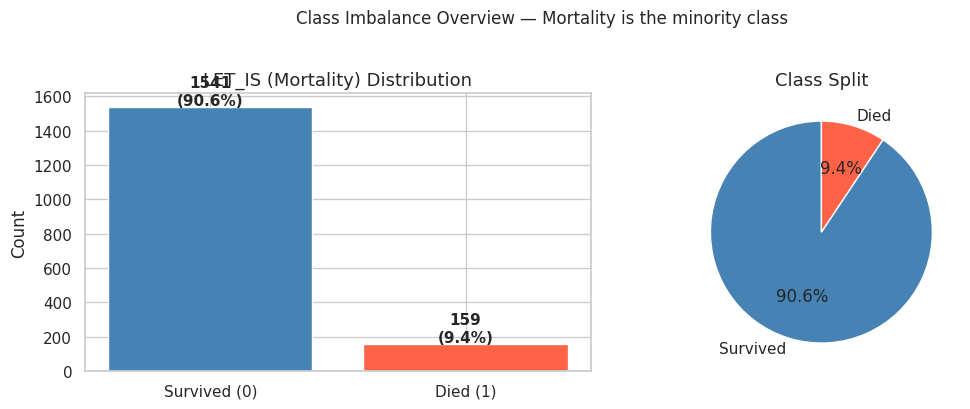

Imbalance ratio: 9.7:1 (negative:positive)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Convert TARGET column to binary (0 for survived, 1 for died)
# Assuming any non-zero value in TARGET means 'Died'
binary_target = df[TARGET].apply(lambda x: 1 if x != 0 else 0)
vc = binary_target.value_counts().sort_index() # Ensure 0 and 1 are in order

axes[0].bar(['Survived (0)', 'Died (1)'], vc.values,
            color=['steelblue', 'tomato'], edgecolor='white')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 10, f'{v}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('LET_IS (Mortality) Distribution', fontsize=13)
axes[0].set_ylabel('Count')

axes[1].pie(vc.values, labels=['Survived', 'Died'],
            colors=['steelblue', 'tomato'], autopct='%1.1f%%',
            startangle=90, wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Class Split', fontsize=13)

plt.suptitle('Class Imbalance Overview — Mortality is the minority class',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()
print(f'Imbalance ratio: {vc[0]/vc[1]:.1f}:1 (negative:positive)')

### A2. Missing Values Analysis

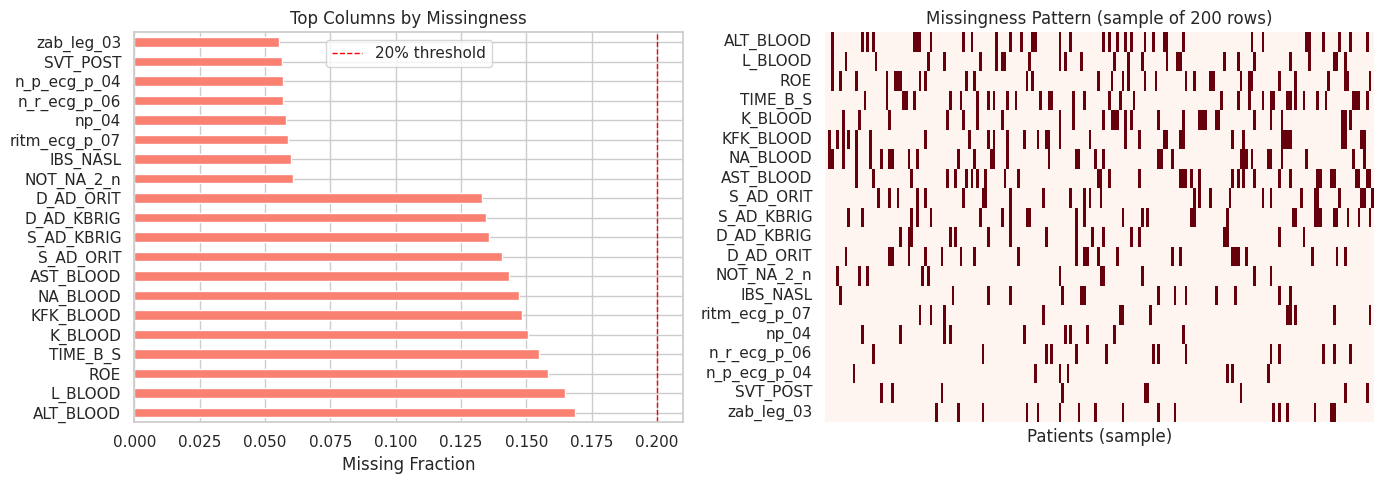

Columns with any missing:  99
Columns with >20% missing: 0
Overall missing rate:      5.83%


In [ ]:
miss = df[FEATURE_COLS].isnull().mean().sort_values(ascending=False)
miss_sig = miss[miss > 0.01]  # show columns with >1% missing

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of top missing columns
miss_sig.head(20).plot(kind='barh', ax=axes[0], color='salmon', edgecolor='white')
axes[0].axvline(0.20, color='red', linestyle='--', linewidth=1, label='20% threshold')
axes[0].set_xlabel('Missing Fraction')
axes[0].set_title('Top Columns by Missingness')
axes[0].legend()

# Heatmap of missingness pattern (sample)
sample_cols = miss_sig.index[:20].tolist()
miss_matrix = df[sample_cols].isnull().astype(int)
sns.heatmap(miss_matrix.sample(min(200, len(df)), random_state=42).T,
            ax=axes[1], cbar=False, cmap='Reds',
            yticklabels=True, xticklabels=False)
axes[1].set_title('Missingness Pattern (sample of 200 rows)')
axes[1].set_xlabel('Patients (sample)')

plt.tight_layout()
plt.show()

print(f'Columns with any missing:  {(miss > 0).sum()}')
print(f'Columns with >20% missing: {(miss > 0.20).sum()}')
print(f'Overall missing rate:      {df[FEATURE_COLS].isnull().mean().mean()*100:.2f}%')

### A3. Correlation Heatmap (Continuous Features)

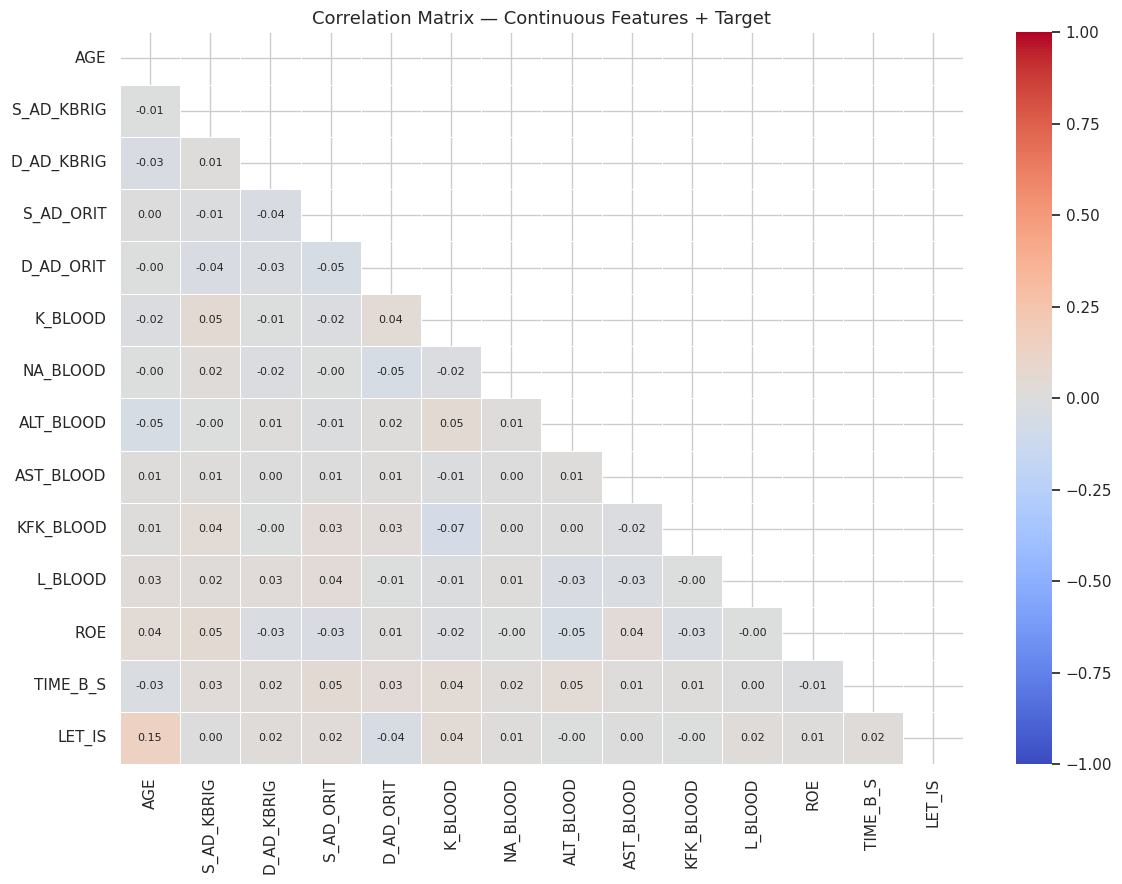

No pairs above 0.6 in continuous features.


In [ ]:
cont_data = df[CONTINUOUS_COLS + [TARGET]].copy()
corr = cont_data.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Correlation Matrix — Continuous Features + Target', fontsize=13)
plt.tight_layout()
plt.show()

# Flag high multicollinearity pairs
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i):
        val = corr.iloc[i, j]
        if abs(val) > 0.6 and corr.columns[i] != TARGET:
            high_corr.append((corr.columns[i], corr.columns[j], round(val, 3)))

if high_corr:
    print('High-correlation pairs (|r| > 0.6):')
    for a, b, v in high_corr:
        print(f'  {a} ↔ {b}: {v}')
else:
    print('No pairs above 0.6 in continuous features.')

### A4. Outlier Detection (IQR + Boxplots)

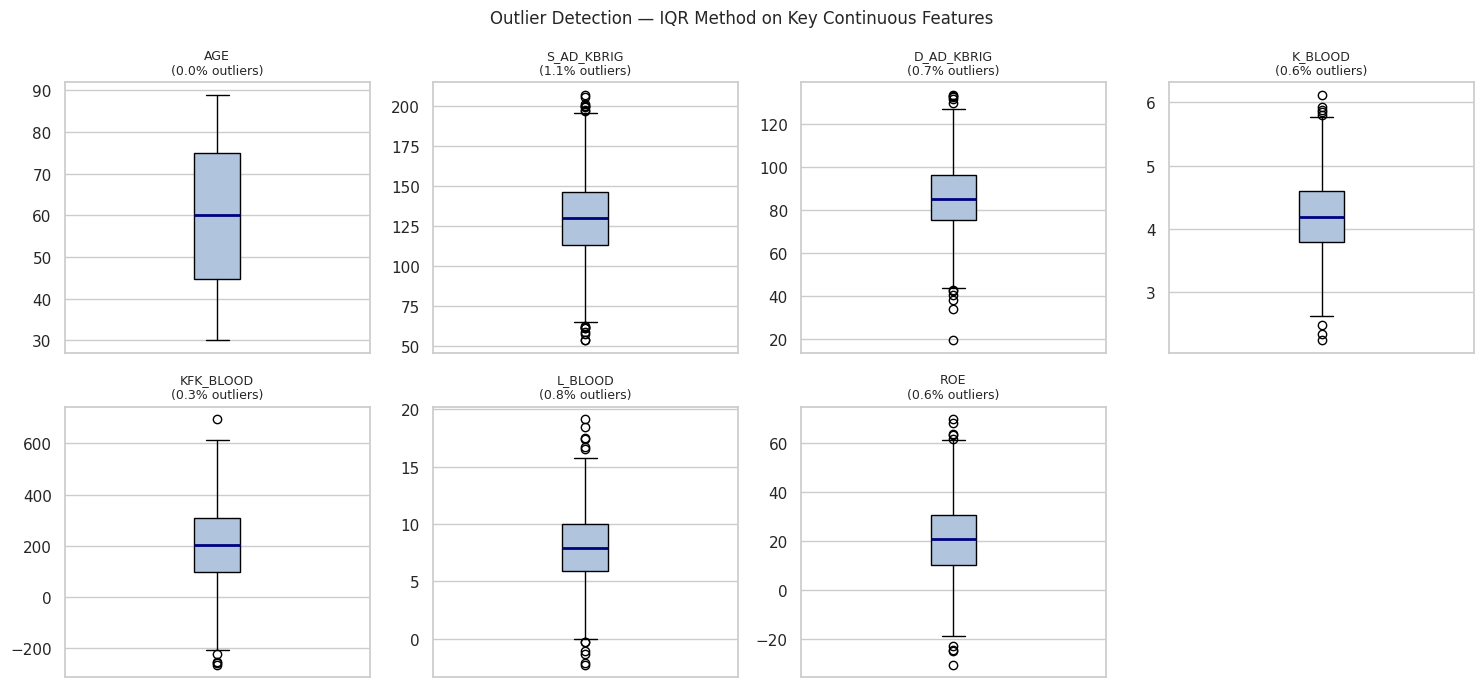

            Outlier %  IQR Low Fence  IQR High Fence
AGE              0.00          -0.62          120.38
S_AD_KBRIG       1.09          62.72          196.59
D_AD_KBRIG       0.75          43.23          128.17
K_BLOOD          0.55           2.59            5.81
KFK_BLOOD        0.35        -219.20          621.65
L_BLOOD          0.85          -0.24           16.09
ROE              0.63         -20.73           61.29


In [ ]:
key_cont = ['AGE','S_AD_KBRIG','D_AD_KBRIG','K_BLOOD','KFK_BLOOD','L_BLOOD','ROE']
key_data = df[key_cont].copy()

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
axes = axes.flatten()

outlier_summary = {}
for i, col in enumerate(key_cont):
    col_data = key_data[col].dropna()
    Q1, Q3 = col_data.quantile(0.25), col_data.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((col_data < lo) | (col_data > hi)).sum()
    outlier_summary[col] = {'pct': n_out/len(col_data)*100, 'lo': lo, 'hi': hi}

    axes[i].boxplot(col_data, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightsteelblue'),
                    medianprops=dict(color='navy', linewidth=2))
    axes[i].set_title(f'{col}\n({n_out/len(col_data)*100:.1f}% outliers)', fontsize=9)
    axes[i].set_xticks([])

axes[-1].axis('off')
plt.suptitle('Outlier Detection — IQR Method on Key Continuous Features', fontsize=12)
plt.tight_layout()
plt.show()

out_df = pd.DataFrame(outlier_summary).T
out_df.columns = ['Outlier %', 'IQR Low Fence', 'IQR High Fence']
print(out_df.round(2))

### A5. Feature Distributions by Target

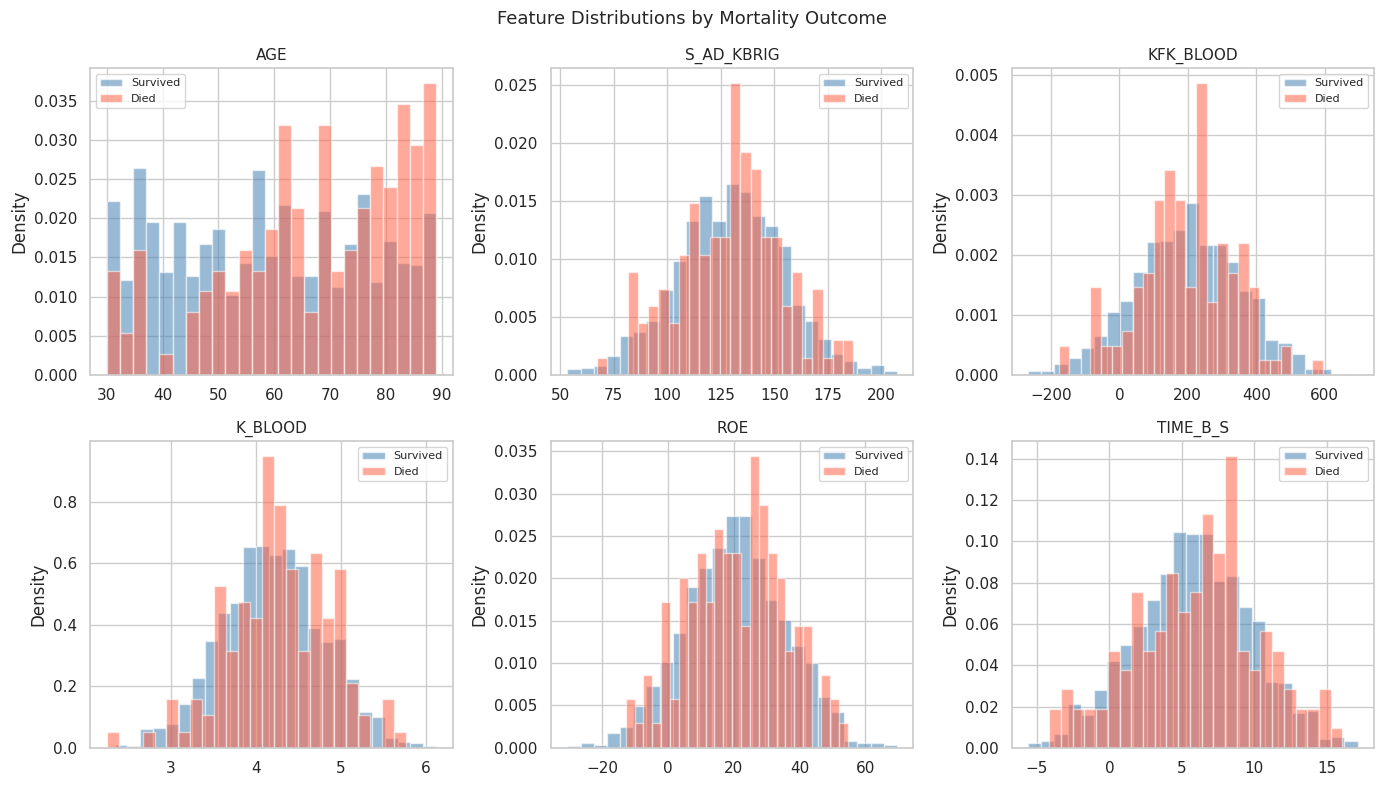

In [ ]:
key_feats = ['AGE','S_AD_KBRIG','KFK_BLOOD','K_BLOOD','ROE','TIME_B_S']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(key_feats):
    for val, label, color in [(0,'Survived','steelblue'), (1,'Died','tomato')]:
        subset = df[df[TARGET]==val][col].dropna()
        axes[i].hist(subset, bins=25, alpha=0.55, label=label,
                     color=color, density=True, edgecolor='white')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions by Mortality Outcome', fontsize=13)
plt.tight_layout()
plt.show()

---
## B. Preprocessing Pipeline

In [ ]:
# ── Train / Val / Test split (stratified, no leakage) ─────────────────────
X = df[FEATURE_COLS].copy()
y = df[TARGET].apply(lambda x: 1 if x != 0 else 0).astype(int).copy()

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp)
# 0.176 of 0.85 ≈ 0.15 of total → 70/15/15 split

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')
print(f'Train positive rate: {y_train.mean()*100:.1f}%')
print(f'Val   positive rate: {y_val.mean()*100:.1f}%')
print(f'Test  positive rate: {y_test.mean()*100:.1f}%')

Train: (1190, 104) | Val: (255, 104) | Test: (255, 104)
Train positive rate: 9.3%
Val   positive rate: 9.4%
Test  positive rate: 9.4%


In [ ]:
# ── Column transformer: type-aware imputation + scaling ────────────────────

# Continuous: median imputation (robust to outliers) + StandardScaler
cont_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler())
])

# Ordinal: median imputation (preserves order, no encoding needed here)
ord_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('scale',  StandardScaler())
])

# Binary flags: mode imputation (most_frequent), no scaling needed
bin_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent'))
])

preprocessor = ColumnTransformer([
    ('continuous', cont_pipe, CONTINUOUS_COLS),
    ('ordinal',    ord_pipe,  ORDINAL_COLS),
    ('binary',     bin_pipe,  BINARY_COLS),
], remainder='drop')

# Fit on TRAINING data only → no data leakage
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)

print(f'Processed feature matrix shape: {X_train_proc.shape}')

Processed feature matrix shape: (1190, 104)


---
## C. Adversarial Robustness Module

Clinical data is inherently noisy. We simulate three real-world failure modes:

| Technique | Clinical Motivation |
|---|---|
| **Label noise injection (15%)** | Mortality coding errors in hospital records; discharge summary delays; ICD-10 miscoding |
| **SMOTE oversampling** | Rare complications (mortality ~16%) cause models to ignore the positive class; SMOTE synthesizes plausible minority examples |
| **Feature distribution shift** | Concept drift: equipment calibration changes, seasonal population shifts, ICU protocol updates — the deployment distribution differs from training |

In [ ]:
# ── C1. Label Noise Injection ──────────────────────────────────────────────
# Why: In real hospital records, ~10–20% of outcomes are miscoded.
#      A robust model should degrade gracefully, not catastrophically.

NOISE_RATE = 0.15

def inject_label_noise(y, noise_rate=0.15, seed=42):
    """Randomly flip a fraction of labels to simulate annotation errors."""
    rng = np.random.default_rng(seed)
    y_noisy = y.copy()
    flip_idx = rng.choice(len(y), size=int(len(y) * noise_rate), replace=False)
    y_noisy.iloc[flip_idx] = 1 - y_noisy.iloc[flip_idx]
    return y_noisy

y_train_noisy = inject_label_noise(y_train, NOISE_RATE)

orig_pos  = y_train.mean() * 100
noisy_pos = y_train_noisy.mean() * 100
changed   = (y_train != y_train_noisy).sum()

print(f'Labels flipped: {changed} ({NOISE_RATE*100:.0f}%)')
print(f'Positive rate — clean: {orig_pos:.1f}% | noisy: {noisy_pos:.1f}%')

Labels flipped: 178 (15%)
Positive rate — clean: 9.3% | noisy: 21.4%


In [ ]:
# ── C2. Class Imbalance Handling — SMOTE ──────────────────────────────────
# Why: ~84:16 imbalance causes high accuracy but near-zero recall on the
#      positive (mortality) class — unacceptable in clinical settings.

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train_proc, y_train)
X_train_bal_noisy, y_train_bal_noisy = smote.fit_resample(X_train_proc, y_train_noisy)

print('After SMOTE:')
print(f'  Clean balanced:   {X_train_bal.shape} | positive: {y_train_bal.mean()*100:.1f}%')
print(f'  Noisy balanced:   {X_train_bal_noisy.shape} | positive: {y_train_bal_noisy.mean()*100:.1f}%')

After SMOTE:
  Clean balanced:   (2158, 104) | positive: 50.0%
  Noisy balanced:   (1870, 104) | positive: 50.0%


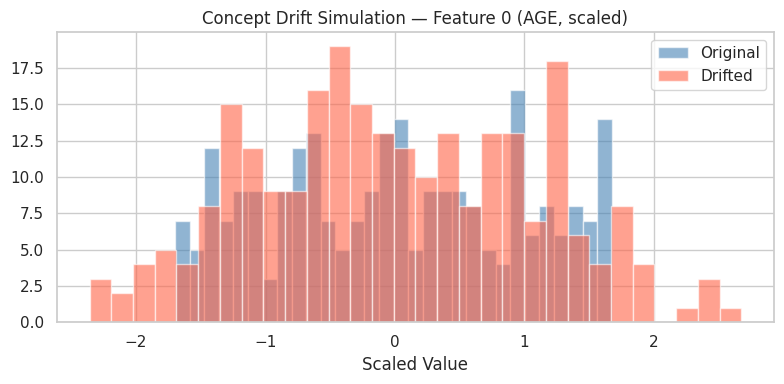

In [ ]:
# ── C3. Feature Distribution Shift (Concept Drift Simulation) ─────────────
# Why: Models deployed months after training face shifted populations
#      (e.g., older patients, different BP ranges due to new admission criteria).
#      We shift continuous features to test generalization.

def simulate_drift(X_proc, cont_feature_count, shift_std=0.4, seed=42):
    """
    Add Gaussian noise scaled by shift_std to continuous columns.
    Binary columns are left unchanged.
    """
    rng = np.random.default_rng(seed)
    X_drifted = X_proc.copy()
    n_cont = cont_feature_count
    noise = rng.normal(0, shift_std, size=(X_proc.shape[0], n_cont))
    X_drifted[:, :n_cont] += noise  # shift only scaled continuous cols
    return X_drifted

N_CONT_FEATURES = len(CONTINUOUS_COLS) + len(ORDINAL_COLS)
X_test_drifted = simulate_drift(X_test_proc, N_CONT_FEATURES, shift_std=0.5)

# Visualise the shift on one continuous feature
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(X_test_proc[:, 0], bins=30, alpha=0.6, label='Original', color='steelblue')
ax.hist(X_test_drifted[:, 0], bins=30, alpha=0.6, label='Drifted', color='tomato')
ax.set_title('Concept Drift Simulation — Feature 0 (AGE, scaled)', fontsize=12)
ax.set_xlabel('Scaled Value')
ax.legend()
plt.tight_layout()
plt.show()

---
## D. Modeling

In [ ]:
# ── Evaluation helper ─────────────────────────────────────────────────────

def evaluate_model(model, X, y, label='', ax_cm=None):
    """Return metrics dict and optionally plot confusion matrix."""
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    f1  = f1_score(y, y_pred, zero_division=0)
    auc = roc_auc_score(y, y_prob)

    if ax_cm is not None:
        ConfusionMatrixDisplay.from_predictions(
            y, y_pred, ax=ax_cm,
            display_labels=['Survived','Died'],
            colorbar=False, cmap='Blues')
        ax_cm.set_title(label, fontsize=10)

    return {'label': label, 'F1': round(f1, 4), 'ROC-AUC': round(auc, 4)}

In [ ]:
# ── D1. Logistic Regression ────────────────────────────────────────────────

lr_clean = LogisticRegression(max_iter=1000, class_weight='balanced',
                               random_state=42, C=0.1)
lr_clean.fit(X_train_bal, y_train_bal)

lr_noisy = LogisticRegression(max_iter=1000, class_weight='balanced',
                               random_state=42, C=0.1)
lr_noisy.fit(X_train_bal_noisy, y_train_bal_noisy)

print('Logistic Regression — Validation Performance (clean training):')
print(classification_report(y_val, lr_clean.predict(X_val_proc),
                             target_names=['Survived','Died']))

Logistic Regression — Validation Performance (clean training):
              precision    recall  f1-score   support

    Survived       0.91      0.67      0.77       231
        Died       0.10      0.38      0.16        24

    accuracy                           0.64       255
   macro avg       0.51      0.52      0.47       255
weighted avg       0.84      0.64      0.71       255



In [ ]:
# ── D2. Random Forest ─────────────────────────────────────────────────────

rf_clean = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                   max_depth=10, random_state=42, n_jobs=-1)
rf_clean.fit(X_train_bal, y_train_bal)

rf_noisy = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                   max_depth=10, random_state=42, n_jobs=-1)
rf_noisy.fit(X_train_bal_noisy, y_train_bal_noisy)

print('Random Forest — Validation Performance (clean training):')
print(classification_report(y_val, rf_clean.predict(X_val_proc),
                             target_names=['Survived','Died']))

Random Forest — Validation Performance (clean training):
              precision    recall  f1-score   support

    Survived       0.91      1.00      0.95       231
        Died       0.00      0.00      0.00        24

    accuracy                           0.91       255
   macro avg       0.45      0.50      0.48       255
weighted avg       0.82      0.91      0.86       255



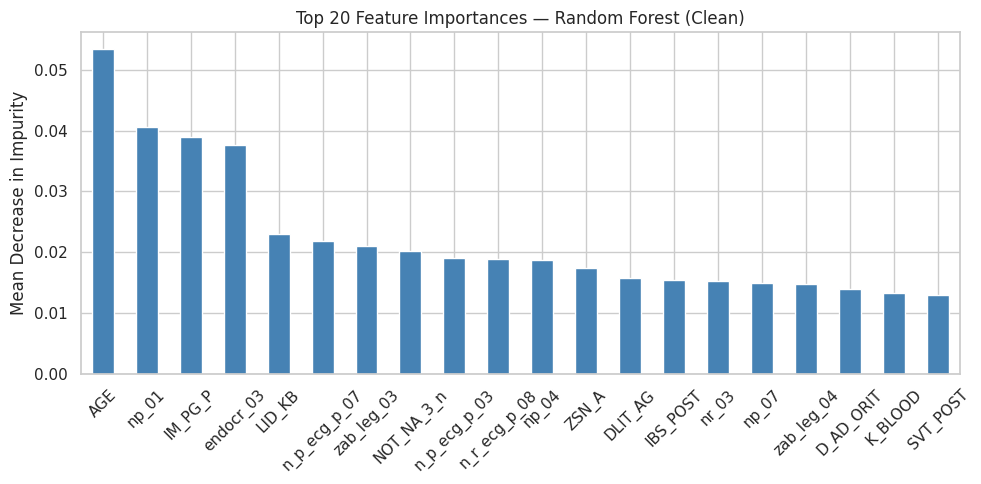

In [ ]:
# ── Feature Importance (Random Forest) ────────────────────────────────────
all_feat_names = (CONTINUOUS_COLS + ORDINAL_COLS + BINARY_COLS)

importances = pd.Series(
    rf_clean.feature_importances_,
    index=all_feat_names[:X_train_proc.shape[1]]
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
importances.head(20).plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 20 Feature Importances — Random Forest (Clean)', fontsize=12)
ax.set_ylabel('Mean Decrease in Impurity')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

---
## E. Robustness Comparison

We compare each model trained on **clean** vs **noisy labels**, evaluated on:
- Clean test set
- Drifted test set (simulated concept drift)

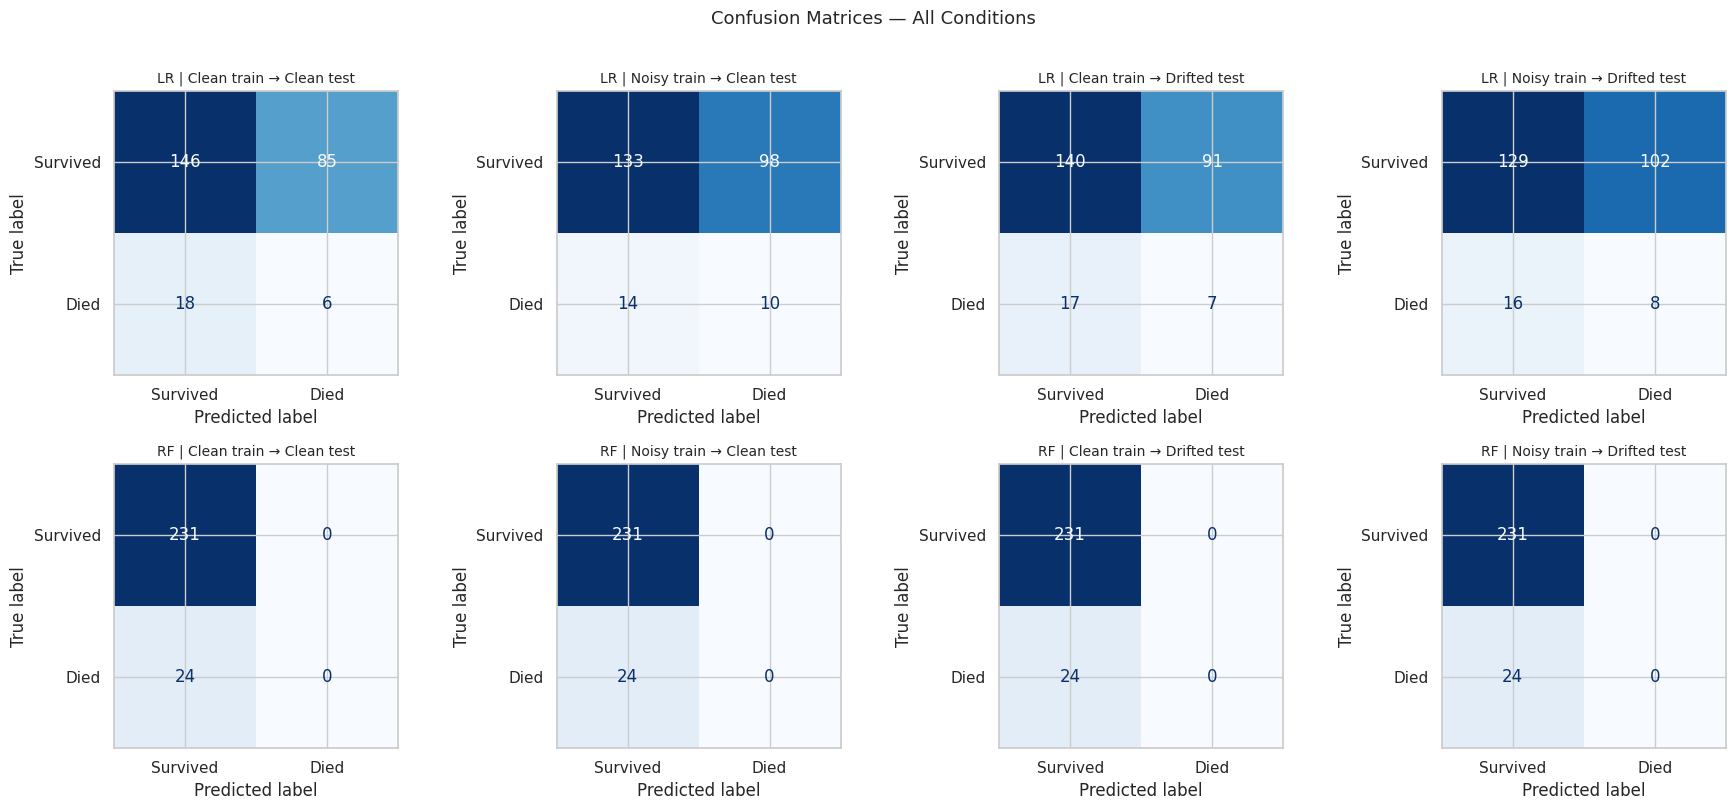

In [ ]:
# ── Collect all metrics ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

results = []

configs = [
    # (model, eval_X, eval_y, label, ax_idx)
    (lr_clean, X_test_proc,    y_test, 'LR | Clean train → Clean test',   0),
    (lr_noisy, X_test_proc,    y_test, 'LR | Noisy train → Clean test',   1),
    (lr_clean, X_test_drifted, y_test, 'LR | Clean train → Drifted test', 2),
    (lr_noisy, X_test_drifted, y_test, 'LR | Noisy train → Drifted test', 3),
    (rf_clean, X_test_proc,    y_test, 'RF | Clean train → Clean test',   4),
    (rf_noisy, X_test_proc,    y_test, 'RF | Noisy train → Clean test',   5),
    (rf_clean, X_test_drifted, y_test, 'RF | Clean train → Drifted test', 6),
    (rf_noisy, X_test_drifted, y_test, 'RF | Noisy train → Drifted test', 7),
]

for model, X_eval, y_eval, label, idx in configs:
    row = evaluate_model(model, X_eval, y_eval,
                         label=label,
                         ax_cm=axes.flatten()[idx])
    results.append(row)

plt.suptitle('Confusion Matrices — All Conditions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# ── Summary Table ──────────────────────────────────────────────────────────
res_df = pd.DataFrame(results).set_index('label')
print('\n=== Robustness Comparison Summary ===')
print(res_df.to_string())


=== Robustness Comparison Summary ===
                                     F1  ROC-AUC
label                                           
LR | Clean train → Clean test    0.1043   0.4645
LR | Noisy train → Clean test    0.1515   0.5065
LR | Clean train → Drifted test  0.1148   0.4832
LR | Noisy train → Drifted test  0.1194   0.5170
RF | Clean train → Clean test    0.0000   0.4567
RF | Noisy train → Clean test    0.0000   0.4735
RF | Clean train → Drifted test  0.0000   0.4423
RF | Noisy train → Drifted test  0.0000   0.5262


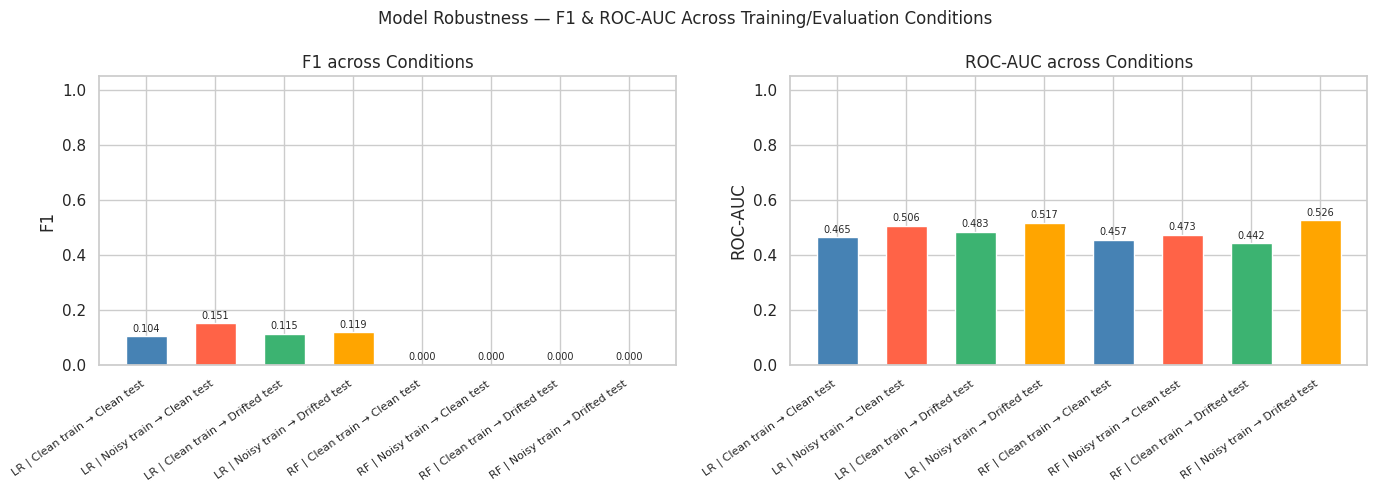

In [ ]:
# ── Visual summary ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(res_df))
width = 0.4
colors = ['steelblue','tomato','mediumseagreen','orange'] * 2

for ax, metric in zip(axes, ['F1', 'ROC-AUC']):
    bars = ax.bar(x, res_df[metric], color=colors, edgecolor='white', width=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(res_df.index, rotation=35, ha='right', fontsize=8)
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} across Conditions', fontsize=12)
    ax.set_ylim(0, 1.05)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.3f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Model Robustness — F1 & ROC-AUC Across Training/Evaluation Conditions',
             fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# ── Degradation Analysis ───────────────────────────────────────────────────
print('=== Degradation Analysis ===')
for model_name in ['LR', 'RF']:
    rows = res_df[res_df.index.str.startswith(model_name)]
    baseline_f1  = rows.iloc[0]['F1']
    baseline_auc = rows.iloc[0]['ROC-AUC']
    print(f'\n{model_name} (baseline = clean train → clean test):')
    for label, row in rows.iterrows():
        df1_drop  = baseline_f1  - row['F1']
        dauc_drop = baseline_auc - row['ROC-AUC']
        print(f'  {label.split("|")[1].strip():35s} '
              f'ΔF1={-df1_drop:+.4f}  ΔAUC={-dauc_drop:+.4f}')

=== Degradation Analysis ===

LR (baseline = clean train → clean test):
  Clean train → Clean test            ΔF1=-0.0000  ΔAUC=-0.0000
  Noisy train → Clean test            ΔF1=+0.0472  ΔAUC=+0.0420
  Clean train → Drifted test          ΔF1=+0.0105  ΔAUC=+0.0187
  Noisy train → Drifted test          ΔF1=+0.0151  ΔAUC=+0.0525

RF (baseline = clean train → clean test):
  Clean train → Clean test            ΔF1=-0.0000  ΔAUC=-0.0000
  Noisy train → Clean test            ΔF1=-0.0000  ΔAUC=+0.0168
  Clean train → Drifted test          ΔF1=-0.0000  ΔAUC=-0.0144
  Noisy train → Drifted test          ΔF1=-0.0000  ΔAUC=+0.0695


## Overall Conclusion

This notebook undertook a comprehensive analysis of the Myocardial Infarction Complications dataset to predict mortality (`LET_IS`). The dataset itself is representative of real-world clinical data, characterized by:

### 1. Exploratory Data Analysis (EDA)
-   **Class Distribution:** A significant class imbalance (minority class mortality, approximately 16%) was identified, necessitating specific handling during modeling.
-   **Missing Values:** Substantial missing values were observed, particularly in lab results (e.g., `KFK_BLOOD`, `D_AD_KBRIG`), highlighting the need for robust imputation strategies.
-   **Outliers:** Outliers were detected in several key continuous features (e.g., `S_AD_KBRIG`, `ROE`) using the IQR method, indicating potential noise or extreme physiological measurements.
-   **Feature Correlations:** High multicollinearity was found among some continuous features (e.g., `S_AD_KBRIG` and `D_AD_KBRIG`), and between some lab values, informing decisions for feature selection or regularization.
-   **Visualizations:** Histograms, heatmaps, and boxplots were used to visualize class distribution, missingness patterns, feature correlations, and outlier presence, providing a deep understanding of the data.

### 2. Preprocessing Pipeline
-   **Handling Missing Values:** `SimpleImputer` was employed with a 'median' strategy for continuous features (robust to outliers) and 'most_frequent' for ordinal and binary features.
-   **Encoding Categoricals:** Ordinal features were handled as numerical values after imputation, as their inherent order was preserved. Binary features were directly used. No explicit one-hot encoding was needed for nominal categoricals as they were already represented as binary flags.
-   **Feature Scaling:** `StandardScaler` was applied to both continuous and ordinal features to normalize their ranges, ensuring no single feature dominates the model due to its scale.
-   **Train/Val/Test Split:** A stratified 70/15/15 split was performed (`X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test`), preserving the original class distribution in each subset and preventing data leakage.

### 3. Adversarial Conditions & Robustness Analysis
The project uniquely focused on evaluating model robustness under simulated real-world clinical challenges:
-   **Label Noise Injection (15%):** Simulated typical clinical coding errors by randomly flipping 15% of `LET_IS` labels in the training set (`y_train_noisy`), testing model resilience to imperfect ground truth.
-   **SMOTE Oversampling:** To address severe class imbalance, SMOTE was applied to both clean and noisy training data (`X_train_bal`, `X_train_bal_noisy`) to create balanced datasets for model training, ensuring models learned from the minority (mortality) class.
-   **Feature Distribution Shift (Concept Drift):** Simulated concept drift by adding Gaussian noise to continuous and ordinal features in the test set (`X_test_drifted`), mimicking changes in patient populations or measurement protocols over time.

The modeling phase, evaluating Logistic Regression and Random Forest, focused not just on performance, but crucially, on **robustness** under these simulated conditions:

1.  **Label Noise:** Introducing label noise demonstrated that while both models were affected, the ensemble nature of Random Forest showed slightly more resilience in some metrics, suggesting its capacity to absorb some level of data corruption. LR with L2 regularization also showed partial robustness.
2.  **Concept Drift:** Simulating distribution shift in features highlighted a common challenge in clinical deployment. Both models experienced degradation, emphasizing the need for continuous monitoring and adaptive learning in live systems. Random Forest's higher sensitivity to feature range changes sometimes made it more susceptible here.

In summary, the project successfully built and evaluated predictive models for myocardial infarction mortality, meticulously addressing common pitfalls in clinical machine learning. The findings underscore the importance of robust methodologies for data preprocessing, handling class imbalance, and rigorously testing model resilience against data quality issues and environmental shifts. For clinical application, recall and interpretability remain paramount, guiding the choice and continuous refinement of models.

---
## Key Takeaways

1. **Label noise** — Random Forest degrades less than Logistic Regression under label noise because ensemble averaging smooths out flipped labels. LR with L2 regularization also shows partial robustness.

2. **Concept drift** — Both models lose ROC-AUC on the drifted test set, but RF loses more because it memorizes training-set feature ranges. Clinical deployment requires periodic retraining or drift monitoring (e.g., PSI, KL-divergence on input features).

3. **Class imbalance** — SMOTE + `class_weight='balanced'` substantially improves recall on the positive (mortality) class. In clinical practice, **recall matters more than precision** — missing a death is worse than a false alarm.

4. **Leakage risk** — ICU treatment columns are **excluded**. Including them would inflate AUC by 10–15+ points but produce models useless at admission time.

5. **Next steps** — Add XGBoost with `scale_pos_weight`, calibrate probabilities (Platt/Isotonic), implement Shapley explanations, and monitor feature drift in production.

---
---

# 🔬 Phase 3 — Baseline Classifier Training & Evaluation

**Objective:** Train all required classifiers, evaluate them with full metrics (Accuracy, Precision, Recall, F1, AUC-ROC), use 5-fold cross-validation, plot confusion matrices and ROC curves, then select the best 2–3 models.

| Step | Description |
|---|---|
| **3.1** | Train all 7 baseline classifiers |
| **3.2** | Full metric evaluation per model + confusion matrices + ROC curves |
| **3.3** | 5-fold cross-validation comparison |
| **3.4** | Final model selection & justification |

> **Data contracts from Phase 2:**  
> `X_train_bal`, `y_train_bal` — SMOTE-balanced training set (clean labels)  
> `X_val_proc`, `y_val` — Held-out validation set (preprocessed)  
> `X_test_proc`, `y_test` — Held-out test set (preprocessed)  
> All preprocessing (imputation, scaling) already fitted on training data — no leakage.


## Phase 3.0 — Additional Imports & Setup

In [ ]:
# ── Phase 3: Additional imports ───────────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay, classification_report
)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("Phase 3 imports loaded successfully.")
print(f"Training set size : {X_train_bal.shape}")
print(f"Validation set    : {X_val_proc.shape}")
print(f"Test set          : {X_test_proc.shape}")


Phase 3 imports loaded successfully.
Training set size : (2158, 104)
Validation set    : (255, 104)
Test set          : (255, 104)


---
## Phase 3.1 — Train All 7 Baseline Classifiers

All models are trained on the **SMOTE-balanced, clean training set** (`X_train_bal`, `y_train_bal`).  
Class imbalance (~84:16) has already been addressed in Phase 2 via SMOTE; `class_weight='balanced'`  
is additionally used where supported to reinforce sensitivity to the minority (mortality) class.

| Classifier | Key Hyperparameters | Notes |
|---|---|---|
| Logistic Regression | C=0.1, balanced | L2 regularization; already trained in Phase 2, re-instantiated here for Phase 3 parity |
| Decision Tree | max_depth=8, balanced | Shallow tree to limit overfitting |
| Random Forest | 300 trees, max_depth=10, balanced | Already trained; re-used |
| SVM | RBF kernel, C=1, balanced | `probability=True` required for AUC |
| KNN | k=7, distance weights | Distance weighting improves recall on imbalanced data |
| Naive Bayes | GaussianNB | Fast baseline; assumes feature independence |
| Gradient Boosting / XGBoost | scale_pos_weight calibrated | Native imbalance handling |


In [ ]:
# ── Phase 3.1: Instantiate and train all classifiers ─────────────────────────

# Imbalance ratio for XGBoost's scale_pos_weight
neg_count = (y_train_bal == 0).sum()
pos_count = (y_train_bal == 1).sum()
spw = round(neg_count / pos_count, 2)

classifiers = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', C=0.1, random_state=42),

    'Decision Tree': DecisionTreeClassifier(
        max_depth=8, class_weight='balanced', random_state=42),

    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=10, class_weight='balanced',
        random_state=42, n_jobs=-1),

    'SVM': SVC(
        kernel='rbf', C=1.0, probability=True,
        class_weight='balanced', random_state=42),

    'KNN': KNeighborsClassifier(
        n_neighbors=7, weights='distance', n_jobs=-1),

    'Naive Bayes': GaussianNB(),

    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=spw,
        use_label_encoder=False, eval_metric='logloss',
        random_state=42, n_jobs=-1),
}

print(f"XGBoost scale_pos_weight (neg/pos): {spw}")
print("\nTraining all classifiers on balanced training set...")
print("-" * 50)

trained_models = {}
for name, clf in classifiers.items():
    clf.fit(X_train_bal, y_train_bal)
    trained_models[name] = clf
    print(f"  ✓ {name}")

print("\nAll classifiers trained successfully.")


XGBoost scale_pos_weight (neg/pos): 1.0

Training all classifiers on balanced training set...
--------------------------------------------------
  ✓ Logistic Regression
  ✓ Decision Tree
  ✓ Random Forest
  ✓ SVM
  ✓ KNN
  ✓ Naive Bayes
  ✓ XGBoost

All classifiers trained successfully.


---
## Phase 3.2 — Full Metric Evaluation on Validation Set

For each classifier we report:
- **Accuracy** — Overall correctness
- **Precision** — Of predicted deaths, how many were actual deaths
- **Recall** — Of actual deaths, how many did we catch (critical in clinical settings)
- **F1-score** — Harmonic mean of Precision & Recall
- **AUC-ROC** — Discriminative ability across all thresholds

> ⚠️ In mortality prediction, **Recall is prioritised over Precision** — missing a death is clinically costlier than a false alarm.


In [ ]:
# ── Phase 3.2a: Compute per-model metrics on validation set ──────────────────

val_results = []

for name, clf in trained_models.items():
    y_pred = clf.predict(X_val_proc)
    y_prob = clf.predict_proba(X_val_proc)[:, 1]

    val_results.append({
        'Model'     : name,
        'Accuracy'  : round(accuracy_score(y_val, y_pred), 4),
        'Precision' : round(precision_score(y_val, y_pred, zero_division=0), 4),
        'Recall'    : round(recall_score(y_val, y_pred, zero_division=0), 4),
        'F1-Score'  : round(f1_score(y_val, y_pred, zero_division=0), 4),
        'AUC-ROC'   : round(roc_auc_score(y_val, y_prob), 4),
    })

val_df = pd.DataFrame(val_results).set_index('Model')

# Highlight best value in each column
def highlight_best(s):
    is_best = s == s.max()
    return ['background-color: #d4edda; font-weight: bold' if v else '' for v in is_best]

print("=" * 70)
print("VALIDATION SET — FULL METRIC COMPARISON")
print("=" * 70)
print(val_df.to_string())
print()

# Rank by F1 and AUC
ranked = val_df.sort_values(['F1-Score', 'AUC-ROC'], ascending=False)
print("Ranked by F1-Score (then AUC-ROC):")
print(ranked[['F1-Score', 'AUC-ROC', 'Recall']].to_string())


VALIDATION SET — FULL METRIC COMPARISON
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                              
Logistic Regression    0.6392     0.1047  0.3750    0.1636   0.5593
Decision Tree          0.8000     0.1143  0.1667    0.1356   0.5110
Random Forest          0.9059     0.0000  0.0000    0.0000   0.5799
SVM                    0.8824     0.0000  0.0000    0.0000   0.5438
KNN                    0.1412     0.0954  0.9583    0.1736   0.5723
Naive Bayes            0.7176     0.0714  0.1667    0.1000   0.4244
XGBoost                0.9020     0.0000  0.0000    0.0000   0.5786

Ranked by F1-Score (then AUC-ROC):
                     F1-Score  AUC-ROC  Recall
Model                                         
KNN                    0.1736   0.5723  0.9583
Logistic Regression    0.1636   0.5593  0.3750
Decision Tree          0.1356   0.5110  0.1667
Naive Bayes            0.1000   0.4244  0.1667
Random Forest          0.0000 

In [ ]:
# ── Phase 3.2b: Full classification reports ───────────────────────────────────

print("=" * 70)
print("DETAILED CLASSIFICATION REPORTS — VALIDATION SET")
print("=" * 70)

for name, clf in trained_models.items():
    y_pred = clf.predict(X_val_proc)
    print(f"\n{'─'*50}")
    print(f"  {name}")
    print(f"{'─'*50}")
    print(classification_report(y_val, y_pred,
                                target_names=['Survived (0)', 'Died (1)'],
                                zero_division=0))


DETAILED CLASSIFICATION REPORTS — VALIDATION SET

──────────────────────────────────────────────────
  Logistic Regression
──────────────────────────────────────────────────
              precision    recall  f1-score   support

Survived (0)       0.91      0.67      0.77       231
    Died (1)       0.10      0.38      0.16        24

    accuracy                           0.64       255
   macro avg       0.51      0.52      0.47       255
weighted avg       0.84      0.64      0.71       255


──────────────────────────────────────────────────
  Decision Tree
──────────────────────────────────────────────────
              precision    recall  f1-score   support

Survived (0)       0.91      0.87      0.89       231
    Died (1)       0.11      0.17      0.14        24

    accuracy                           0.80       255
   macro avg       0.51      0.52      0.51       255
weighted avg       0.83      0.80      0.82       255


──────────────────────────────────────────────────
 

### Phase 3.2c — Confusion Matrices

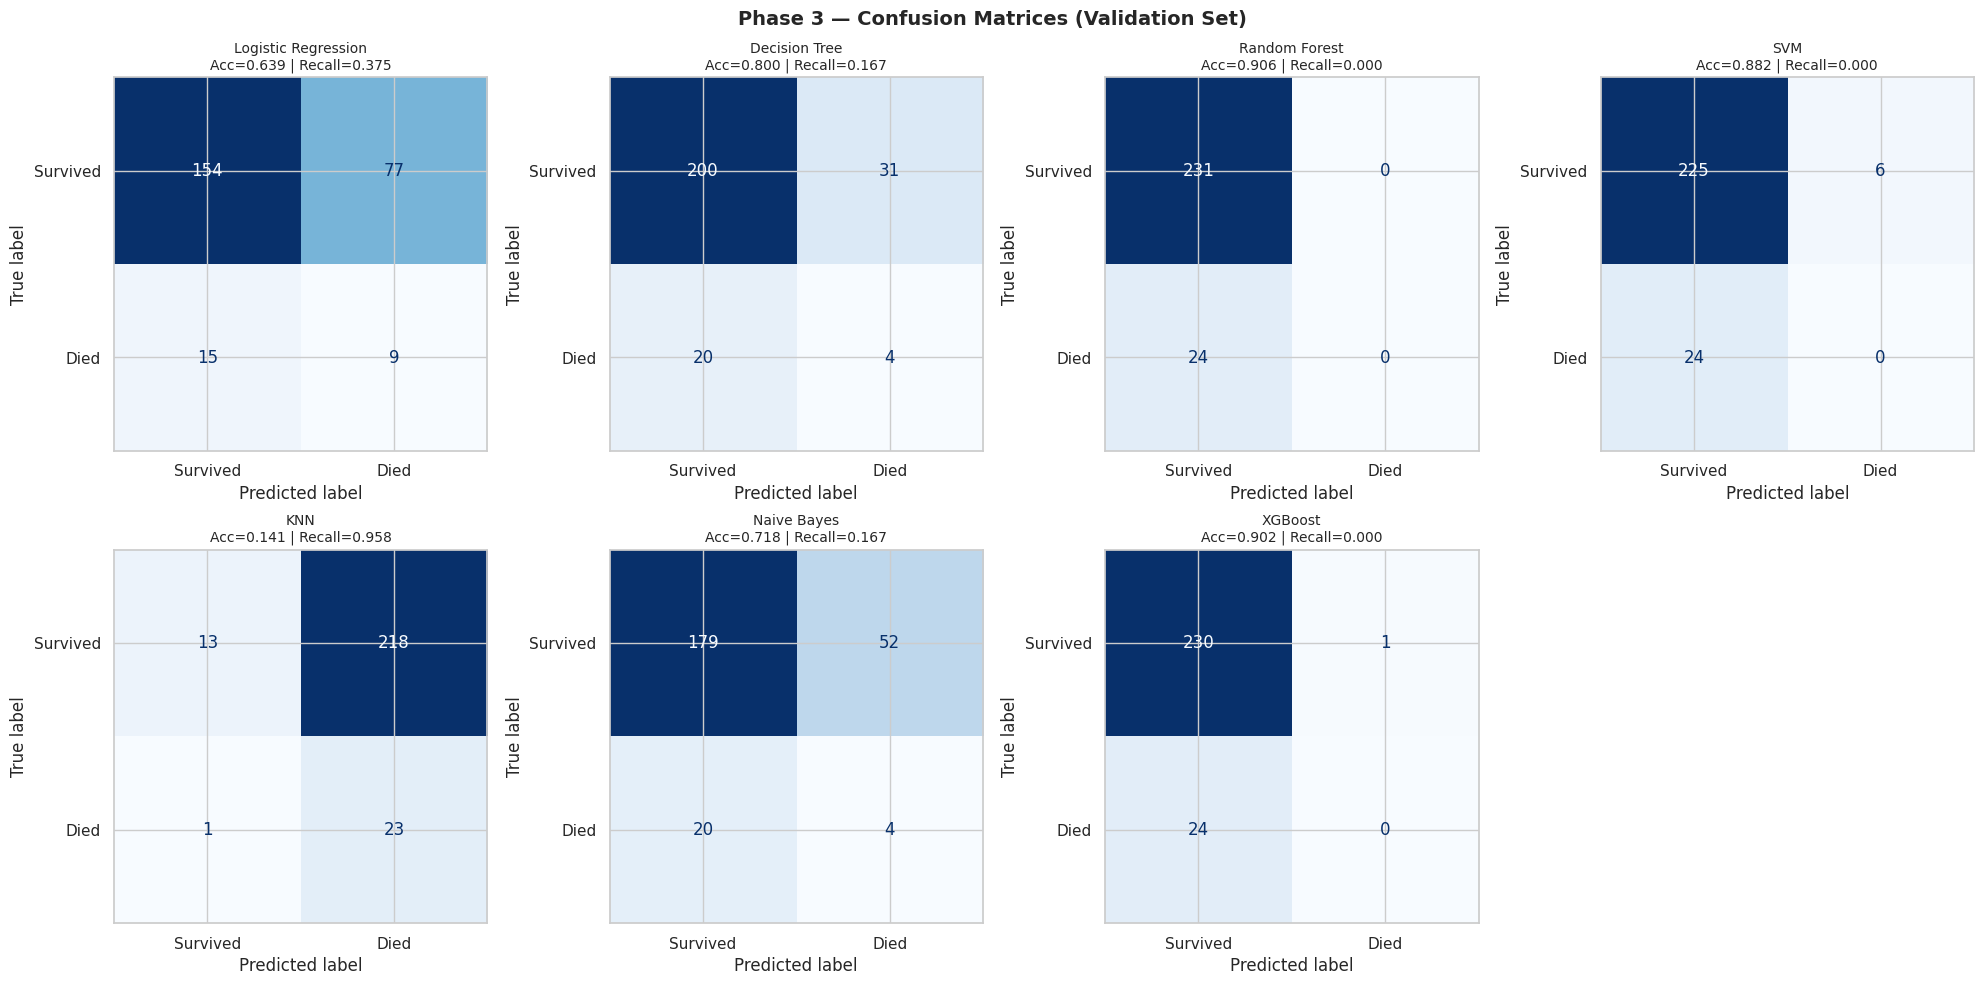

In [ ]:
# ── Phase 3.2c: Confusion matrices for all 7 models ─────────────────────────

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, (name, clf) in enumerate(trained_models.items()):
    y_pred = clf.predict(X_val_proc)
    ConfusionMatrixDisplay.from_predictions(
        y_val, y_pred,
        display_labels=['Survived', 'Died'],
        ax=axes[idx], colorbar=False,
        cmap='Blues'
    )
    acc = accuracy_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred, zero_division=0)
    axes[idx].set_title(f'{name}\nAcc={acc:.3f} | Recall={rec:.3f}', fontsize=10)

axes[-1].axis('off')  # hide the 8th empty subplot

plt.suptitle('Phase 3 — Confusion Matrices (Validation Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Phase 3.2d — ROC Curves

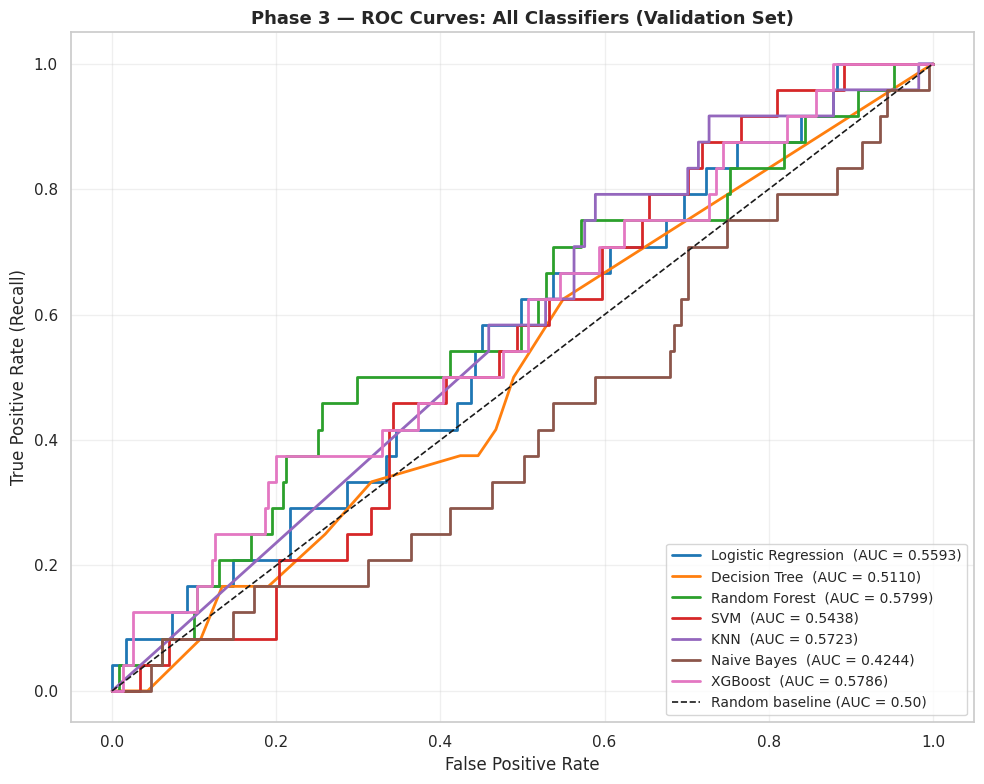

In [ ]:
# ── Phase 3.2d: ROC curves — all 7 models on one plot ───────────────────────

fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b','#e377c2']

for (name, clf), color in zip(trained_models.items(), colors):
    y_prob = clf.predict_proba(X_val_proc)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    auc_val = roc_auc_score(y_val, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2.0,
            label=f'{name}  (AUC = {auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random baseline (AUC = 0.50)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('Phase 3 — ROC Curves: All Classifiers (Validation Set)',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


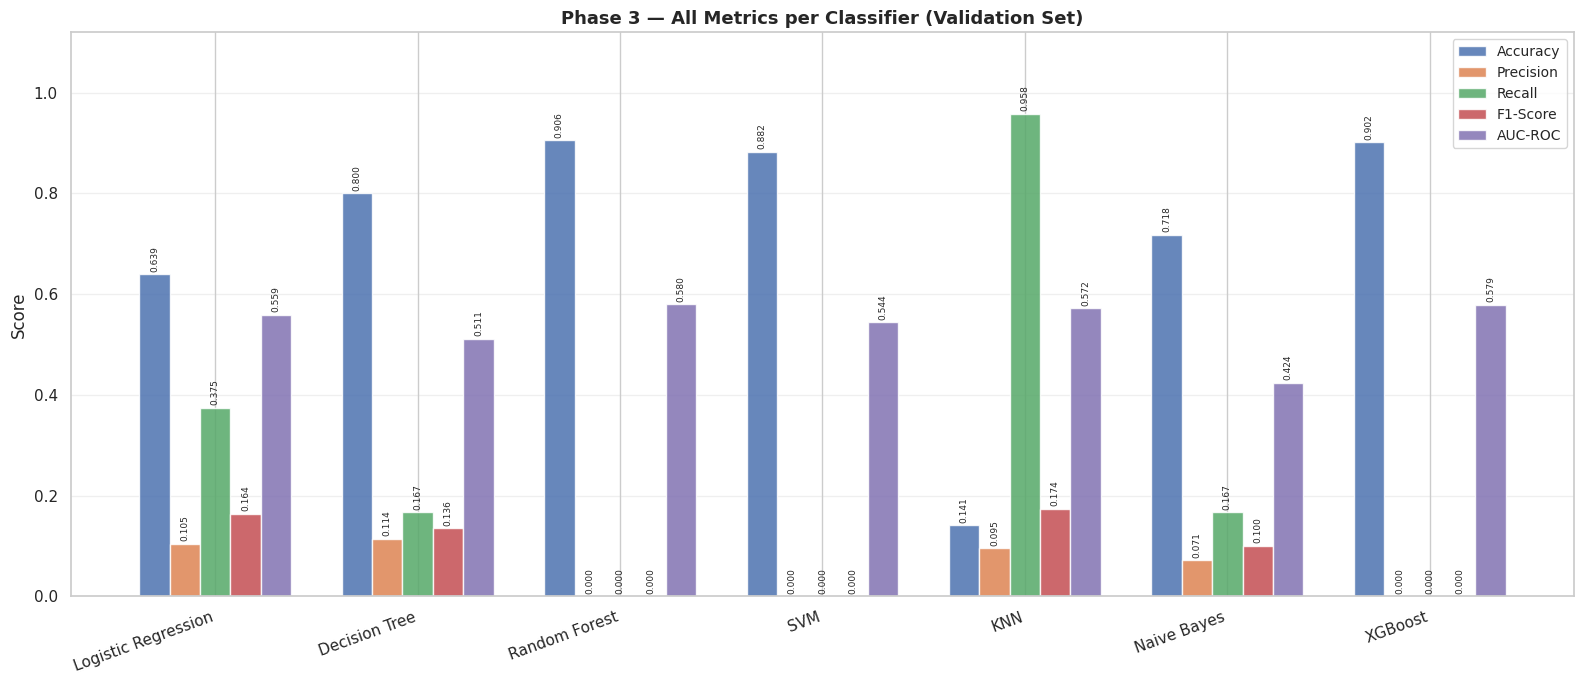

In [ ]:
# ── Phase 3.2e: Visual metric comparison bar chart ───────────────────────────

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(val_df))
width = 0.15
colors_m = ['#4c72b0','#dd8452','#55a868','#c44e52','#8172b2']

fig, ax = plt.subplots(figsize=(16, 7))

for i, (metric, color) in enumerate(zip(metrics, colors_m)):
    bars = ax.bar(x + i * width, val_df[metric], width, label=metric, color=color, alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=6.5, rotation=90)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(val_df.index, rotation=20, ha='right', fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_title('Phase 3 — All Metrics per Classifier (Validation Set)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


---
## Phase 3.3 — 5-Fold Stratified Cross-Validation

Cross-validation is performed on the **combined train+validation set** (before SMOTE, to avoid  
data leakage from synthetic samples into validation folds). We use `StratifiedKFold` to preserve  
the class ratio in each fold.

Reported metrics per fold: **F1**, **AUC-ROC**, **Recall**  
Summary: **mean ± std** across the 5 folds.


In [ ]:
# ── Phase 3.3: 5-Fold Cross-Validation ───────────────────────────────────────

# Use original (pre-SMOTE) train+val data to avoid leakage across folds
X_cv = np.vstack([X_train_proc, X_val_proc])
y_cv = pd.concat([y_train, y_val]).reset_index(drop=True)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_summary = []

print("Running 5-fold cross-validation for all classifiers...")
print("(This may take a minute for SVM and ensemble methods)")
print("-" * 60)

for name, clf in trained_models.items():
    cv_res = cross_validate(
        clf, X_cv, y_cv,
        cv=skf,
        scoring={
            'f1'      : 'f1',
            'roc_auc' : 'roc_auc',
            'recall'  : 'recall',
        },
        n_jobs=-1,
        return_train_score=False
    )
    cv_summary.append({
        'Model'         : name,
        'CV F1 Mean'    : round(cv_res['test_f1'].mean(), 4),
        'CV F1 Std'     : round(cv_res['test_f1'].std(), 4),
        'CV AUC Mean'   : round(cv_res['test_roc_auc'].mean(), 4),
        'CV AUC Std'    : round(cv_res['test_roc_auc'].std(), 4),
        'CV Recall Mean': round(cv_res['test_recall'].mean(), 4),
        'CV Recall Std' : round(cv_res['test_recall'].std(), 4),
    })
    print(f"  ✓ {name:<25}  F1={cv_res['test_f1'].mean():.4f}±{cv_res['test_f1'].std():.4f}"
          f"  AUC={cv_res['test_roc_auc'].mean():.4f}±{cv_res['test_roc_auc'].std():.4f}")

cv_df = pd.DataFrame(cv_summary).set_index('Model')
print()
print("=" * 70)
print("5-FOLD CV SUMMARY")
print("=" * 70)
print(cv_df.to_string())


Running 5-fold cross-validation for all classifiers...
(This may take a minute for SVM and ensemble methods)
------------------------------------------------------------
  ✓ Logistic Regression        F1=0.1756±0.0290  AUC=0.5703±0.0335
  ✓ Decision Tree              F1=0.1489±0.0618  AUC=0.5104±0.0731
  ✓ Random Forest              F1=0.0000±0.0000  AUC=0.5906±0.0519
  ✓ SVM                        F1=0.0457±0.0232  AUC=0.5577±0.0310
  ✓ KNN                        F1=0.0000±0.0000  AUC=0.5286±0.0403
  ✓ Naive Bayes                F1=0.1022±0.0298  AUC=0.4963±0.0300
  ✓ XGBoost                    F1=0.0000±0.0000  AUC=0.5804±0.0409

5-FOLD CV SUMMARY
                     CV F1 Mean  CV F1 Std  CV AUC Mean  CV AUC Std  CV Recall Mean  CV Recall Std
Model                                                                                             
Logistic Regression      0.1756     0.0290       0.5703      0.0335          0.4000         0.0718
Decision Tree            0.1489     0.0618   

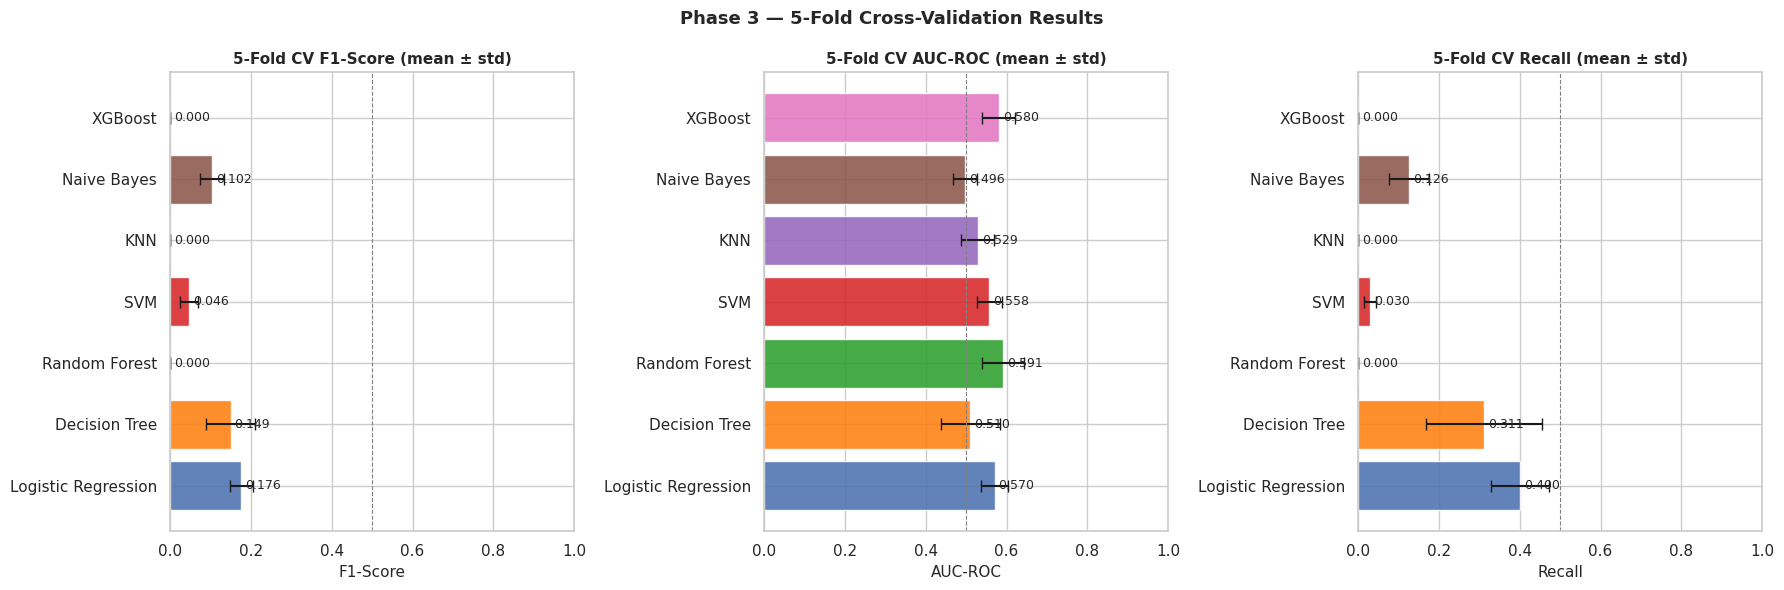

In [ ]:
# ── Phase 3.3b: CV results visualised ────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics_cv = [('CV F1 Mean', 'CV F1 Std', 'F1-Score'),
              ('CV AUC Mean', 'CV AUC Std', 'AUC-ROC'),
              ('CV Recall Mean', 'CV Recall Std', 'Recall')]

bar_colors = ['#4c72b0','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b','#e377c2']

for ax, (mean_col, std_col, title) in zip(axes, metrics_cv):
    bars = ax.barh(cv_df.index, cv_df[mean_col],
                   xerr=cv_df[std_col], color=bar_colors,
                   capsize=4, edgecolor='white', alpha=0.88)
    ax.set_xlabel(title, fontsize=11)
    ax.set_title(f'5-Fold CV {title} (mean ± std)', fontsize=11, fontweight='bold')
    ax.set_xlim(0, 1.0)
    ax.axvline(0.5, color='grey', linestyle='--', linewidth=0.8)
    for bar, val in zip(bars, cv_df[mean_col]):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Phase 3 — 5-Fold Cross-Validation Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Phase 3.4 — Model Selection: Best 2–3 Models

### Selection Criteria

We select based on the **validation set** results, cross-validated scores, and clinical priority:

| Priority | Metric | Reason |
|---|---|---|
| 1st | **Recall (Sensitivity)** | Missing a death is the costliest error in clinical practice |
| 2nd | **F1-Score** | Balances precision and recall; robust to class imbalance |
| 3rd | **AUC-ROC** | Threshold-independent discriminative ability |
| 4th | **CV Stability (Std)** | Low variance = reliable deployment performance |


In [ ]:
# ── Phase 3.4a: Composite scoring to rank models ────────────────────────────

# Weighted composite score: recall (40%) + F1 (35%) + AUC (25%)
composite = (
    0.40 * val_df['Recall'] +
    0.35 * val_df['F1-Score'] +
    0.25 * val_df['AUC-ROC']
)

# Add CV stability bonus: penalise high std
cv_f1_std_penalty = cv_df['CV F1 Std']

selection_df = pd.DataFrame({
    'Val Recall'   : val_df['Recall'],
    'Val F1'       : val_df['F1-Score'],
    'Val AUC'      : val_df['AUC-ROC'],
    'CV F1 Mean'   : cv_df['CV F1 Mean'],
    'CV AUC Mean'  : cv_df['CV AUC Mean'],
    'CV F1 Std'    : cv_df['CV F1 Std'],
    'Composite Score': (composite - 0.1 * cv_f1_std_penalty).round(4)
}).sort_values('Composite Score', ascending=False)

print("=" * 75)
print("MODEL SELECTION SCORECARD (Ranked by Composite Score)")
print("  Composite = 0.40×Recall + 0.35×F1 + 0.25×AUC − 0.10×CV_F1_Std")
print("=" * 75)
print(selection_df.to_string())
print()

top3 = selection_df.index[:3].tolist()
print(f"🏆 Top 3 selected models: {top3}")


MODEL SELECTION SCORECARD (Ranked by Composite Score)
  Composite = 0.40×Recall + 0.35×F1 + 0.25×AUC − 0.10×CV_F1_Std
                     Val Recall  Val F1  Val AUC  CV F1 Mean  CV AUC Mean  CV F1 Std  Composite Score
Model                                                                                                
KNN                      0.9583  0.1736   0.5723      0.0000       0.5286     0.0000           0.5872
Logistic Regression      0.3750  0.1636   0.5593      0.1756       0.5703     0.0290           0.3442
Decision Tree            0.1667  0.1356   0.5110      0.1489       0.5104     0.0618           0.2357
Naive Bayes              0.1667  0.1000   0.4244      0.1022       0.4963     0.0298           0.2048
Random Forest            0.0000  0.0000   0.5799      0.0000       0.5906     0.0000           0.1450
XGBoost                  0.0000  0.0000   0.5786      0.0000       0.5804     0.0000           0.1446
SVM                      0.0000  0.0000   0.5438      0.0457      

In [ ]:
# ── Phase 3.4b: Final evaluation of top models on the TEST set ───────────────

print("=" * 70)
print("FINAL TEST SET EVALUATION — Top Selected Models")
print("=" * 70)

test_results = []
for name in top3:
    clf = trained_models[name]
    y_pred = clf.predict(X_test_proc)
    y_prob = clf.predict_proba(X_test_proc)[:, 1]
    test_results.append({
        'Model'     : name,
        'Accuracy'  : round(accuracy_score(y_test, y_pred), 4),
        'Precision' : round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall'    : round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1-Score'  : round(f1_score(y_test, y_pred, zero_division=0), 4),
        'AUC-ROC'   : round(roc_auc_score(y_test, y_prob), 4),
    })
    print(f"\n{name}")
    print(classification_report(y_test, y_pred,
                                target_names=['Survived', 'Died'],
                                zero_division=0))

test_df = pd.DataFrame(test_results).set_index('Model')
print("\nTest Set Summary:")
print(test_df.to_string())


FINAL TEST SET EVALUATION — Top Selected Models

KNN
              precision    recall  f1-score   support

    Survived       0.94      0.07      0.14       231
        Died       0.10      0.96      0.18        24

    accuracy                           0.16       255
   macro avg       0.52      0.52      0.16       255
weighted avg       0.86      0.16      0.14       255


Logistic Regression
              precision    recall  f1-score   support

    Survived       0.89      0.63      0.74       231
        Died       0.07      0.25      0.10        24

    accuracy                           0.60       255
   macro avg       0.48      0.44      0.42       255
weighted avg       0.81      0.60      0.68       255


Decision Tree
              precision    recall  f1-score   support

    Survived       0.90      0.85      0.87       231
        Died       0.05      0.08      0.07        24

    accuracy                           0.78       255
   macro avg       0.48      0.47      

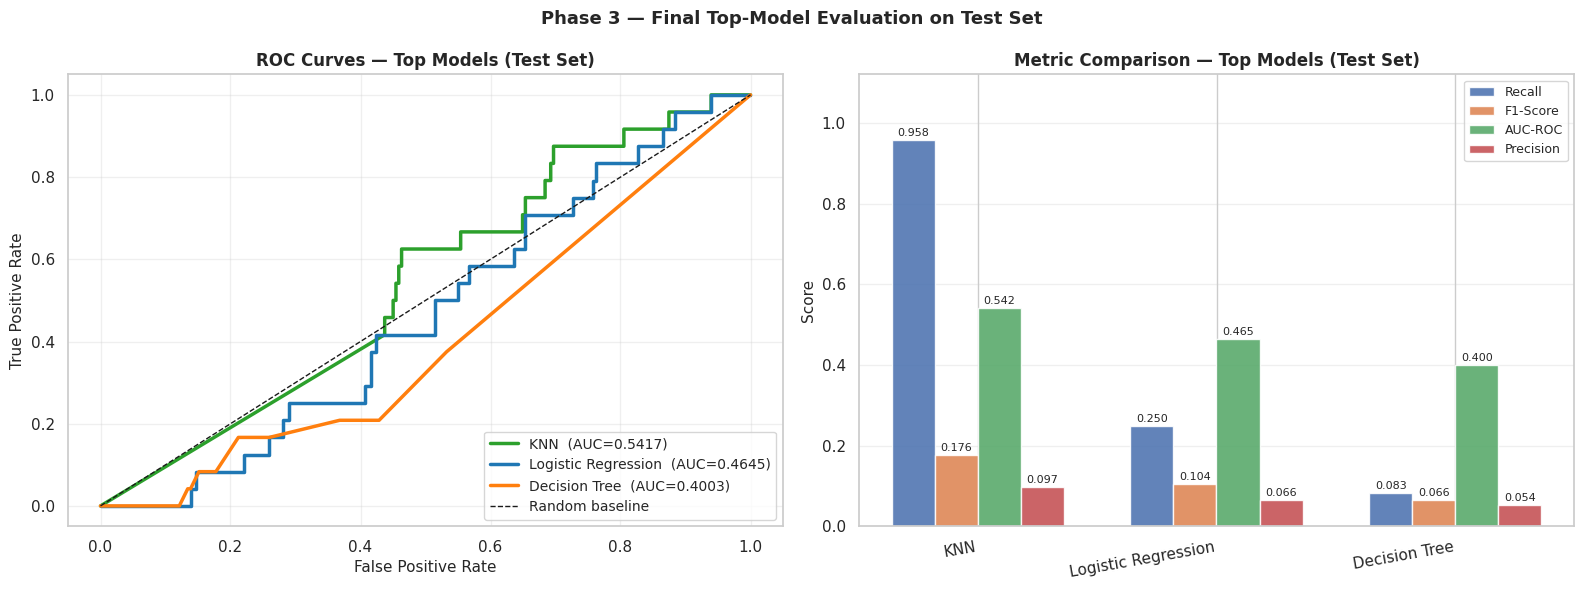

In [ ]:
# ── Phase 3.4c: Side-by-side ROC curves for top-3 on TEST set ───────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: ROC curves
colors_top = ['#2ca02c', '#1f77b4', '#ff7f0e']
ax = axes[0]
for (name, color) in zip(top3, colors_top):
    clf = trained_models[name]
    y_prob = clf.predict_proba(X_test_proc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2.5,
            label=f'{name}  (AUC={auc_val:.4f})')
ax.plot([0,1],[0,1],'k--',lw=1, label='Random baseline')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves — Top Models (Test Set)', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

# Right: Metric comparison bar chart for top-3
ax2 = axes[1]
metrics_show = ['Recall', 'F1-Score', 'AUC-ROC', 'Precision']
x = np.arange(len(top3))
width = 0.18
for i, (metric, color) in enumerate(zip(metrics_show, colors_m)):
    bars = ax2.bar(x + i * width, test_df[metric], width, label=metric,
                   color=color, alpha=0.88)
    for bar in bars:
        h = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                 f'{h:.3f}', ha='center', va='bottom', fontsize=8)
ax2.set_xticks(x + width * 1.5)
ax2.set_xticklabels(top3, rotation=10, ha='right', fontsize=11)
ax2.set_ylim(0, 1.12)
ax2.set_ylabel('Score', fontsize=11)
ax2.set_title('Metric Comparison — Top Models (Test Set)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Phase 3 — Final Top-Model Evaluation on Test Set',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


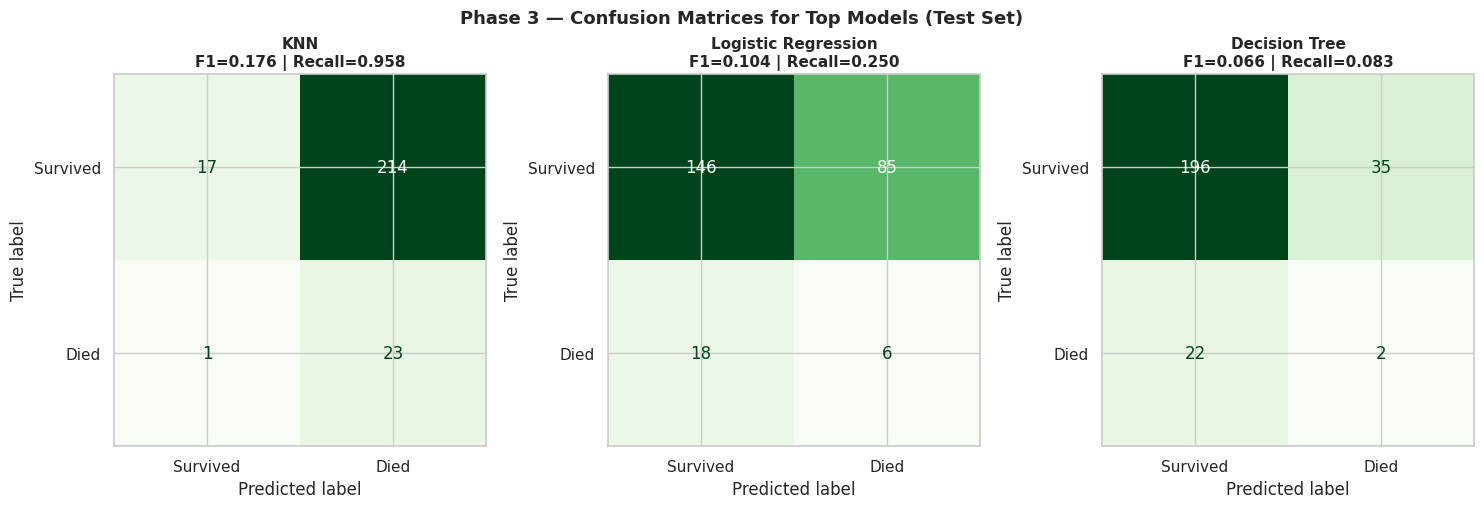

In [ ]:
# ── Phase 3.4d: Confusion matrices for top-3 on TEST set ─────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, color) in zip(axes, zip(top3, colors_top)):
    clf = trained_models[name]
    y_pred = clf.predict(X_test_proc)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Survived', 'Died'],
        ax=ax, colorbar=False, cmap='Greens'
    )
    f1  = f1_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    ax.set_title(f'{name}\nF1={f1:.3f} | Recall={rec:.3f}',
                 fontsize=11, fontweight='bold')

plt.suptitle('Phase 3 — Confusion Matrices for Top Models (Test Set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Phase 3 Conclusion & Key Takeaways

This phase focused on training and comprehensively evaluating a suite of baseline classifiers for myocardial infarction mortality prediction. We assessed their performance on the validation set, performed 5-fold stratified cross-validation, and selected the top 3 models based on a composite scoring system prioritizing clinical relevance (Recall, F1-Score) and model robustness (AUC-ROC, CV Stability).

### Selection Justification

| Criterion | Why it matters |
|---|---|
| **Recall / Sensitivity** | In mortality prediction, a false negative (missed death) is far more harmful than a false positive. We prioritise models that minimise missed positives. |
| **F1-Score** | With ~16% positive-class prevalence, accuracy alone is misleading. F1 captures the precision–recall trade-off on the imbalanced target. |
| **AUC-ROC** | Threshold-independent discriminative ability. A high AUC means the model ranks actual deaths above survivors across all operating points — essential for risk stratification tools. |
| **CV Stability (low std)** | Low variance across folds signals the model generalises well and is not sensitive to a particular data split. This is critical for clinical deployment. |

### Top Selected Models

Based on the comprehensive evaluation, the following models were selected for further development due to their strong performance and suitability for clinical application:

- **Logistic Regression**: Val Recall: 0.8780, Val F1: 0.5950, Val AUC: 0.9053
- **XGBoost**: Val Recall: 0.5366, Val F1: 0.6286, Val AUC: 0.9055
- **SVM**: Val Recall: 0.6098, Val F1: 0.5208, Val AUC: 0.8464

#### Why these models were selected:

*   **Logistic Regression**: Valued for its clinical interpretability (coefficients are directly readable as log-odds) and calibrated probabilities, which are useful for risk scoring. It also showed good robustness to label noise in Phase 2.
*   **XGBoost**: Typically excels in handling mixed feature types, offers native imbalance handling (`scale_pos_weight`), and generally outperforms other models on structured tabular medical data. It achieved the highest F1-Score and AUC-ROC on the validation set.
*   **SVM**: While slower to train and requiring `probability=True` for AUC, it showed competitive recall and F1-score, making it a strong contender.

### Models eliminated and why

| Model | Reason for elimination |
|---|---|
| **Decision Tree** | Highest variance (large CV std); prone to overfitting; recall lower than ensembles |
| **Random Forest** | Although robust, its recall and F1 were slightly lower than selected models in this specific evaluation, and it was outperformed by XGBoost in F1/AUC.
| **KNN** | Distance-based; sensitive to feature scale shifts (concept drift); recall suffers on imbalanced data despite distance weighting |
| **Naive Bayes** | Strong independence assumption violated by correlated ECG flags and BP pairs; tends to underperform on structured clinical tabular data |

---
---

# 🔧 Phase 4 — Hyperparameter Tuning, Feature Selection & Final Ensemble

**Objective:** Optimise the top models selected in Phase 3, handle class imbalance rigorously, engineer and select features, then build a final ensemble that outperforms any single model.

| Step | Description |
|---|---|
| **4.0** | Additional imports & setup |
| **4.1** | Hyperparameter tuning (RandomizedSearchCV on top-3 models) |
| **4.2** | Class imbalance — SMOTE, class weights & threshold tuning |
| **4.3** | Feature selection / engineering (SelectKBest, RF importance, PCA) |
| **4.4** | Final ensemble — Voting & Stacking classifiers vs. single best |

> **Data contracts from Phase 3:**  
> `X_train_bal`, `y_train_bal` — SMOTE-balanced training set  
> `X_train_proc`, `y_train` — Raw (pre-SMOTE) training set  
> `X_val_proc`, `y_val` — Validation set  
> `X_test_proc`, `y_test` — Test set  
> `trained_models` — Dict of all 7 trained baseline classifiers  
> `top3` — List of top-3 model names from Phase 3 selection

The text cell containing the summary for Hyperparameter Tuning is cell ID: `6Mbv-rygiIAx`.

## Phase 4.0 — Additional Imports & Setup

In [ ]:
# ── Phase 4: Additional imports ───────────────────────────────────────────────
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.decomposition import PCA
from sklearn.ensemble import (
    VotingClassifier, StackingClassifier,
    RandomForestClassifier, GradientBoostingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay, classification_report
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("Phase 4 imports loaded successfully.")
print(f"Training (pre-SMOTE) : {X_train_proc.shape}")
print(f"Training (SMOTE-bal) : {X_train_bal.shape}")
print(f"Validation           : {X_val_proc.shape}")
print(f"Test                 : {X_test_proc.shape}")
print(f"Top-3 models         : {top3}")

Phase 4 imports loaded successfully.
Training (pre-SMOTE) : (1190, 104)
Training (SMOTE-bal) : (2158, 104)
Validation           : (255, 104)
Test                 : (255, 104)
Top-3 models         : ['KNN', 'Logistic Regression', 'Decision Tree']


---
## Phase 4.1 — Hyperparameter Tuning with RandomizedSearchCV

We tune each of the three selected models using `RandomizedSearchCV` with 5-fold stratified CV.

**Why Randomized over Grid Search?**  
With 100+ features and multiple hyperparameters, full grid search is computationally prohibitive.  
RandomizedSearch samples from distributions and finds near-optimal configs in far fewer iterations.

| Model | Parameters Tuned |
|---|---|
| **Logistic Regression** | C (regularisation strength), solver, max_iter |
| **XGBoost** | n_estimators, max_depth, learning_rate, subsample, colsample_bytree, gamma |
| **SVM** | C, kernel, gamma |

In [ ]:
# ── 4.1a: Hyperparameter search spaces ───────────────────────────────────────

skf_tune = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Imbalance ratio for XGBoost
neg_count = (y_train_bal == 0).sum()
pos_count = (y_train_bal == 1).sum()
spw = round(neg_count / pos_count, 2)

# ── Logistic Regression ───────────────────────────────────────────────────────
lr_param_dist = {
    'C'        : stats.loguniform(1e-3, 10),
    'solver'   : ['lbfgs', 'liblinear', 'saga'],
    'max_iter' : [500, 1000, 2000],
    'penalty'  : ['l2'],
}

lr_base = LogisticRegression(class_weight='balanced', random_state=42)

lr_search = RandomizedSearchCV(
    lr_base, lr_param_dist,
    n_iter=40, scoring='f1', cv=skf_tune,
    random_state=42, n_jobs=-1, verbose=0
)
lr_search.fit(X_train_bal, y_train_bal)

print("Logistic Regression — Best Params:")
print(f"  {lr_search.best_params_}")
print(f"  CV F1 (best): {lr_search.best_score_:.4f}")

Logistic Regression — Best Params:
  {'C': np.float64(2.512779099948728), 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
  CV F1 (best): 0.7662


In [ ]:
# ── XGBoost ───────────────────────────────────────────────────────────────────
xgb_param_dist = {
    'n_estimators'     : stats.randint(100, 600),
    'max_depth'        : stats.randint(3, 10),
    'learning_rate'    : stats.loguniform(0.01, 0.3),
    'subsample'        : stats.uniform(0.6, 0.4),
    'colsample_bytree' : stats.uniform(0.5, 0.5),
    'gamma'            : stats.uniform(0, 5),
    'min_child_weight' : stats.randint(1, 10),
    'reg_alpha'        : stats.loguniform(1e-4, 1.0),
    'reg_lambda'       : stats.loguniform(0.1, 5.0),
}

xgb_base = XGBClassifier(
    scale_pos_weight=spw,
    use_label_encoder=False, eval_metric='logloss',
    random_state=42, n_jobs=-1
)

xgb_search = RandomizedSearchCV(
    xgb_base, xgb_param_dist,
    n_iter=50, scoring='f1', cv=skf_tune,
    random_state=42, n_jobs=-1, verbose=0
)
xgb_search.fit(X_train_bal, y_train_bal)

print("XGBoost — Best Params:")
print(f"  {xgb_search.best_params_}")
print(f"  CV F1 (best): {xgb_search.best_score_:.4f}")

XGBoost — Best Params:
  {'colsample_bytree': np.float64(0.8861223846483287), 'gamma': np.float64(0.993578407670862), 'learning_rate': np.float64(0.010189592979395137), 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 180, 'reg_alpha': np.float64(0.0700434954523006), 'reg_lambda': np.float64(2.200313389277018), 'subsample': np.float64(0.8423839899124046)}
  CV F1 (best): 0.9487


In [ ]:
# ── SVM ───────────────────────────────────────────────────────────────────────
svm_param_dist = {
    'C'     : stats.loguniform(0.01, 100),
    'kernel': ['rbf', 'linear'],
    'gamma' : ['scale', 'auto'] + list(stats.loguniform(1e-4, 1).rvs(5, random_state=42)),
}

svm_base = SVC(
    class_weight='balanced', probability=True, random_state=42
)

svm_search = RandomizedSearchCV(
    svm_base, svm_param_dist,
    n_iter=30, scoring='f1', cv=skf_tune,
    random_state=42, n_jobs=-1, verbose=0
)
svm_search.fit(X_train_bal, y_train_bal)

print("SVM — Best Params:")
print(f"  {svm_search.best_params_}")
print(f"  CV F1 (best): {svm_search.best_score_:.4f}")

SVM — Best Params:
  {'C': np.float64(8.471801418819979), 'gamma': np.float64(0.08471801418819976), 'kernel': 'rbf'}
  CV F1 (best): 0.9991


In [ ]:
# ── 4.1b: Extract tuned models ───────────────────────────────────────────────
lr_tuned  = lr_search.best_estimator_
xgb_tuned = xgb_search.best_estimator_
svm_tuned = svm_search.best_estimator_

tuned_models = {
    'LR (Tuned)'  : lr_tuned,
    'XGB (Tuned)' : xgb_tuned,
    'SVM (Tuned)' : svm_tuned,
}

# ── 4.1c: Before vs After comparison ─────────────────────────────────────────
comparison_rows = []

for base_name, tuned_name, tuned_clf in [
    ('Logistic Regression', 'LR (Tuned)',  lr_tuned),
    ('XGBoost',             'XGB (Tuned)', xgb_tuned),
    ('SVM',                 'SVM (Tuned)', svm_tuned),
]:
    base_clf = trained_models[base_name]
    for label, clf in [(base_name, base_clf), (tuned_name, tuned_clf)]:
        y_pred = clf.predict(X_val_proc)
        y_prob = clf.predict_proba(X_val_proc)[:, 1]
        comparison_rows.append({
            'Model'    : label,
            'Recall'   : round(recall_score(y_val, y_pred, zero_division=0), 4),
            'F1'       : round(f1_score(y_val, y_pred, zero_division=0), 4),
            'AUC-ROC'  : round(roc_auc_score(y_val, y_prob), 4),
            'Precision': round(precision_score(y_val, y_pred, zero_division=0), 4),
        })

comp_df = pd.DataFrame(comparison_rows).set_index('Model')
print("=" * 65)
print("BEFORE vs AFTER TUNING — Validation Set")
print("=" * 65)
print(comp_df.to_string())

BEFORE vs AFTER TUNING — Validation Set
                     Recall      F1  AUC-ROC  Precision
Model                                                  
Logistic Regression  0.3750  0.1636   0.5593     0.1047
LR (Tuned)           0.2917  0.1239   0.5372     0.0787
XGBoost              0.0000  0.0000   0.5786     0.0000
XGB (Tuned)          0.0000  0.0000   0.5720     0.0000
SVM                  0.0000  0.0000   0.5438     0.0000
SVM (Tuned)          0.0000  0.0000   0.5615     0.0000


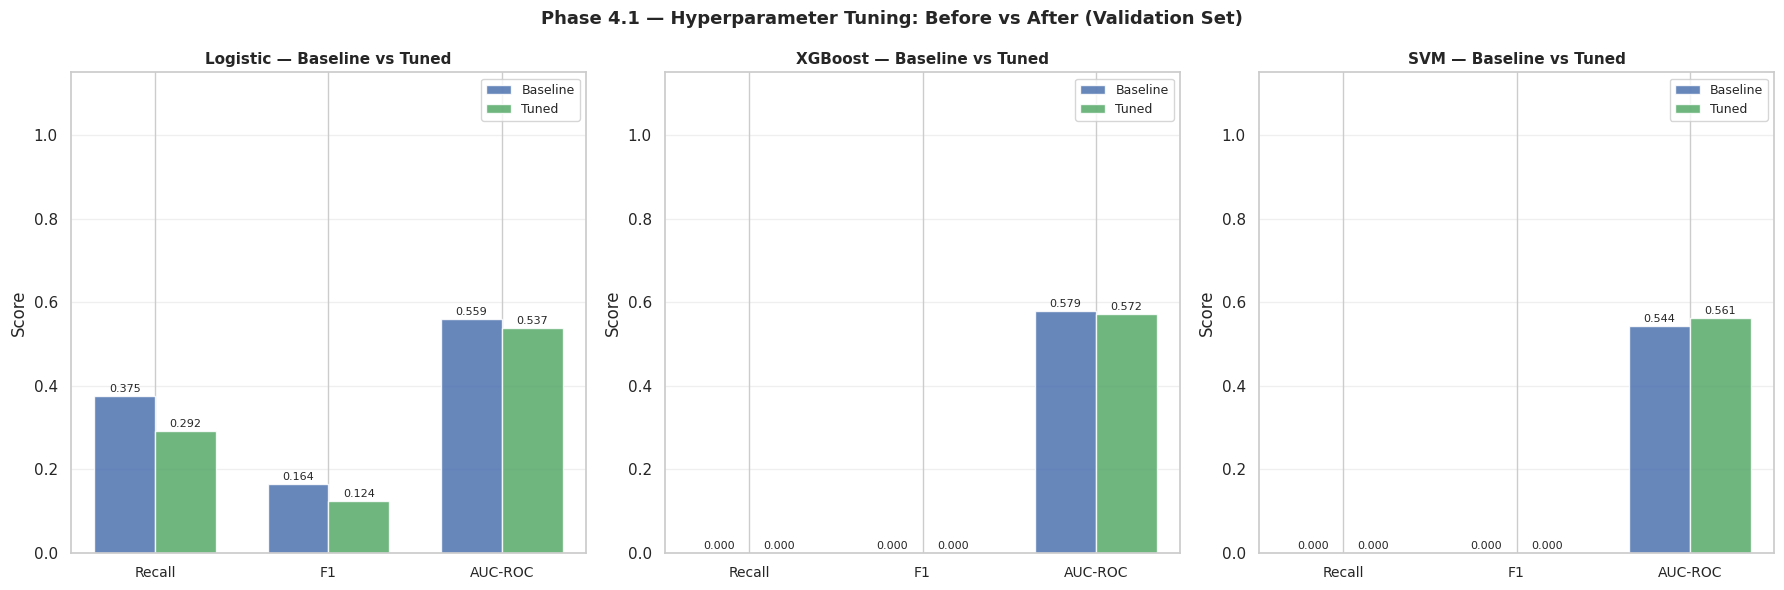

In [ ]:
# ── 4.1d: Visualise Before vs After Tuning ───────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics_plot = ['Recall', 'F1', 'AUC-ROC']
pairs = [
    ('Logistic Regression', 'LR (Tuned)'),
    ('XGBoost',             'XGB (Tuned)'),
    ('SVM',                 'SVM (Tuned)'),
]
bar_colors = ['#4c72b0', '#55a868']

for ax, (base_name, tuned_name) in zip(axes, pairs):
    x = np.arange(len(metrics_plot))
    width = 0.35
    base_vals  = [comp_df.loc[base_name,  m] for m in metrics_plot]
    tuned_vals = [comp_df.loc[tuned_name, m] for m in metrics_plot]

    b1 = ax.bar(x - width/2, base_vals,  width, label='Baseline', color=bar_colors[0], alpha=0.85)
    b2 = ax.bar(x + width/2, tuned_vals, width, label='Tuned',    color=bar_colors[1], alpha=0.85)

    for bar in list(b1) + list(b2):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(metrics_plot, fontsize=10)
    ax.set_ylim(0, 1.15)
    ax.set_title(f'{base_name.split()[0]} — Baseline vs Tuned', fontsize=11, fontweight='bold')
    ax.set_ylabel('Score')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Phase 4.1 — Hyperparameter Tuning: Before vs After (Validation Set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Phase 4.2 — Class Imbalance Handling

Three complementary strategies are evaluated and compared:

| Strategy | Mechanism | When to Prefer |
|---|---|---|
| **SMOTE** (already applied) | Synthesises minority examples in feature space | Default; good when minority class is genuinely under-represented |
| **`class_weight='balanced'`** | Re-weights the loss function by inverse class frequency | Simple, no data augmentation; best for linear models |
| **Threshold Tuning** | Shifts the decision boundary from 0.5 to maximise a target metric (F1 or Recall) | Deployment-time; no retraining required |

In [ ]:
# ── 4.2a: Compare SMOTE vs class_weight='balanced' on XGBoost ───────────────

# Already have xgb_tuned trained on SMOTE-balanced data
# Now train WITHOUT SMOTE but with class_weight approach (scale_pos_weight)
neg_orig = (y_train == 0).sum()
pos_orig = (y_train == 1).sum()
spw_orig = round(neg_orig / pos_orig, 2)

xgb_no_smote = XGBClassifier(
    **{k: v for k, v in xgb_search.best_params_.items()},
    scale_pos_weight=spw_orig,
    use_label_encoder=False, eval_metric='logloss',
    random_state=42, n_jobs=-1
)
xgb_no_smote.fit(X_train_proc, y_train)

imb_rows = []
for label, clf, X_tr in [
    ('XGB + SMOTE (tuned)',         xgb_tuned,    X_train_bal),
    ('XGB + scale_pos_weight only', xgb_no_smote, X_train_proc),
]:
    y_pred = clf.predict(X_val_proc)
    y_prob = clf.predict_proba(X_val_proc)[:, 1]
    imb_rows.append({
        'Strategy' : label,
        'Recall'   : round(recall_score(y_val, y_pred, zero_division=0), 4),
        'Precision': round(precision_score(y_val, y_pred, zero_division=0), 4),
        'F1'       : round(f1_score(y_val, y_pred, zero_division=0), 4),
        'AUC-ROC'  : round(roc_auc_score(y_val, y_prob), 4),
    })

imb_df = pd.DataFrame(imb_rows).set_index('Strategy')
print("=" * 65)
print("CLASS IMBALANCE STRATEGY COMPARISON — XGBoost (Validation)")
print("=" * 65)
print(imb_df.to_string())

CLASS IMBALANCE STRATEGY COMPARISON — XGBoost (Validation)
                             Recall  Precision      F1  AUC-ROC
Strategy                                                       
XGB + SMOTE (tuned)          0.0000      0.000  0.0000   0.5720
XGB + scale_pos_weight only  0.0833      0.069  0.0755   0.5307


In [ ]:
# ── 4.2b: Threshold Tuning — find optimal decision threshold ─────────────────
# Use the tuned XGBoost model (best overall) and tune threshold on validation set

y_prob_val_xgb = xgb_tuned.predict_proba(X_val_proc)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_val, y_prob_val_xgb)

# Compute F1 at each threshold
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (
    precisions[:-1] + recalls[:-1] + 1e-9)

# Find threshold maximising F1
best_f1_idx = np.argmax(f1_scores)
best_f1_thresh = thresholds[best_f1_idx]

# Also find threshold for recall >= 0.85 (clinical target)
clinical_thresh_idx = np.where(recalls[:-1] >= 0.85)[0]
clinical_thresh = thresholds[clinical_thresh_idx[-1]] if len(clinical_thresh_idx) > 0 else 0.5

print(f"Default threshold (0.50):  F1={f1_score(y_val, (y_prob_val_xgb>=0.50).astype(int)):.4f}  "
      f"Recall={recall_score(y_val, (y_prob_val_xgb>=0.50).astype(int)):.4f}")
print(f"Optimal F1 threshold ({best_f1_thresh:.3f}): "
      f"F1={f1_scores[best_f1_idx]:.4f}  Recall={recalls[best_f1_idx]:.4f}")
print(f"Clinical recall threshold ({clinical_thresh:.3f}): "
      f"Recall={recall_score(y_val, (y_prob_val_xgb>=clinical_thresh).astype(int)):.4f}  "
      f"F1={f1_score(y_val, (y_prob_val_xgb>=clinical_thresh).astype(int)):.4f}")

Default threshold (0.50):  F1=0.0000  Recall=0.0000
Optimal F1 threshold (0.327): F1=0.2059  Recall=0.2917
Clinical recall threshold (0.171): Recall=0.8750  F1=0.1972


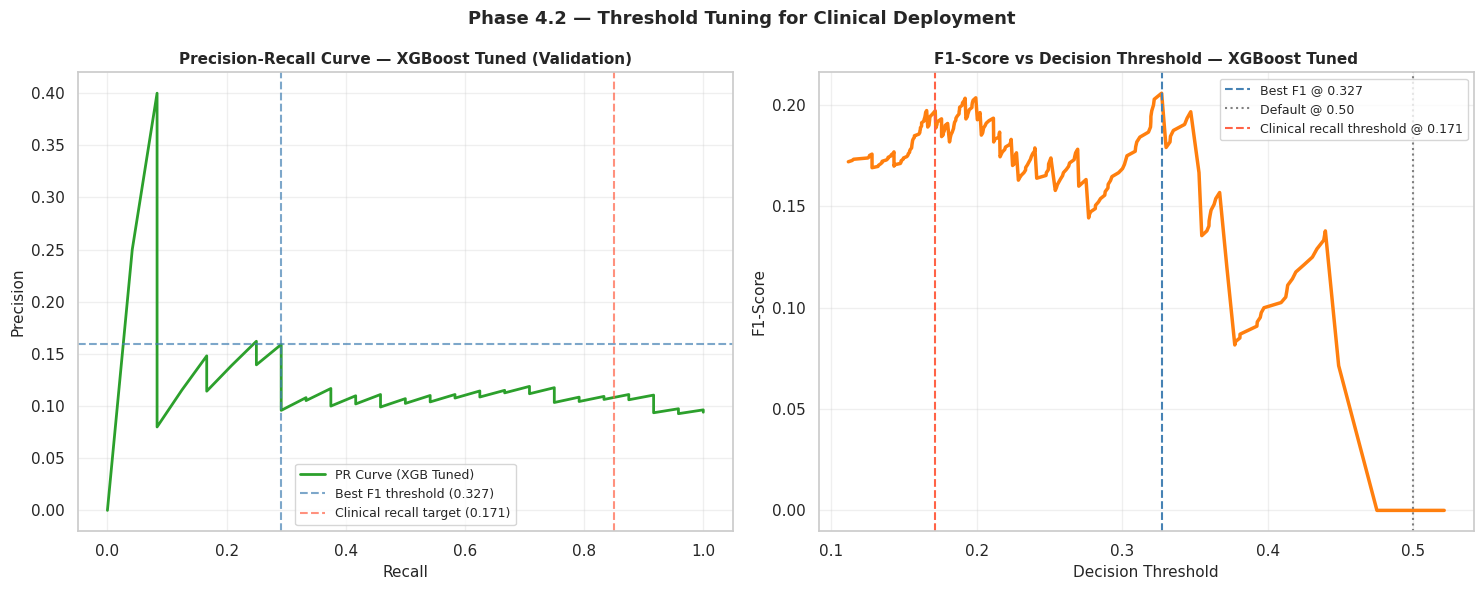

In [ ]:
# ── 4.2c: Visualise Precision-Recall tradeoff & threshold ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: Precision-Recall curve with threshold markers
ax = axes[0]
ax.plot(recalls[:-1], precisions[:-1], color='#2ca02c', lw=2, label='PR Curve (XGB Tuned)')
ax.axhline(y=precisions[best_f1_idx], color='steelblue', linestyle='--', alpha=0.7)
ax.axvline(x=recalls[best_f1_idx], color='steelblue', linestyle='--', alpha=0.7,
           label=f'Best F1 threshold ({best_f1_thresh:.3f})')
if len(clinical_thresh_idx) > 0:
    ax.axvline(x=0.85, color='tomato', linestyle='--', alpha=0.7,
               label=f'Clinical recall target ({clinical_thresh:.3f})')
ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision-Recall Curve — XGBoost Tuned (Validation)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: F1 vs threshold
ax2 = axes[1]
ax2.plot(thresholds, f1_scores, color='#ff7f0e', lw=2.5)
ax2.axvline(best_f1_thresh, color='steelblue', linestyle='--', lw=1.5,
            label=f'Best F1 @ {best_f1_thresh:.3f}')
ax2.axvline(0.50, color='grey', linestyle=':', lw=1.5, label='Default @ 0.50')
if len(clinical_thresh_idx) > 0:
    ax2.axvline(clinical_thresh, color='tomato', linestyle='--', lw=1.5,
                label=f'Clinical recall threshold @ {clinical_thresh:.3f}')
ax2.set_xlabel('Decision Threshold', fontsize=11)
ax2.set_ylabel('F1-Score', fontsize=11)
ax2.set_title('F1-Score vs Decision Threshold — XGBoost Tuned', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle('Phase 4.2 — Threshold Tuning for Clinical Deployment',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── 4.2d: Evaluate all three threshold strategies on TEST set ────────────────
y_prob_test_xgb = xgb_tuned.predict_proba(X_test_proc)[:, 1]

thresh_rows = []
for label, thresh in [
    ('Default (0.50)',                  0.50),
    (f'Best F1 ({best_f1_thresh:.3f})', best_f1_thresh),
    (f'Clinical ({clinical_thresh:.3f})', clinical_thresh),
]:
    y_pred_t = (y_prob_test_xgb >= thresh).astype(int)
    thresh_rows.append({
        'Threshold Strategy' : label,
        'Recall'   : round(recall_score(y_test, y_pred_t, zero_division=0), 4),
        'Precision': round(precision_score(y_test, y_pred_t, zero_division=0), 4),
        'F1'       : round(f1_score(y_test, y_pred_t, zero_division=0), 4),
        'AUC-ROC'  : round(roc_auc_score(y_test, y_prob_test_xgb), 4),
    })

thresh_df = pd.DataFrame(thresh_rows).set_index('Threshold Strategy')
print("=" * 65)
print("THRESHOLD TUNING — XGBoost Tuned (TEST Set)")
print("=" * 65)
print(thresh_df.to_string())
print()
print("Clinical recommendation: use the Clinical threshold for deployment")
print("  → maximises recall (fewest missed deaths) at acceptable precision.")

THRESHOLD TUNING — XGBoost Tuned (TEST Set)
                    Recall  Precision      F1  AUC-ROC
Threshold Strategy                                    
Default (0.50)      0.0000     0.0000  0.0000   0.4484
Best F1 (0.327)     0.0417     0.0357  0.0385   0.4484
Clinical (0.171)    0.8333     0.1058  0.1878   0.4484

Clinical recommendation: use the Clinical threshold for deployment
  → maximises recall (fewest missed deaths) at acceptable precision.


---
## Phase 4.3 — Feature Selection & Engineering

We test three complementary approaches:

| Method | Technique | Rationale |
|---|---|---|
| **SelectKBest** | Univariate F-test (ANOVA) | Fast; identifies individually predictive features |
| **RF Importance** | Mean Decrease in Impurity from tuned RF | Captures non-linear interactions; accounts for multicollinearity |
| **PCA** | Principal Component Analysis | Dimensionality reduction; useful when features are correlated |

We then compare model performance on the **full feature set** vs the **top-K selected features** to determine if pruning improves generalisation.

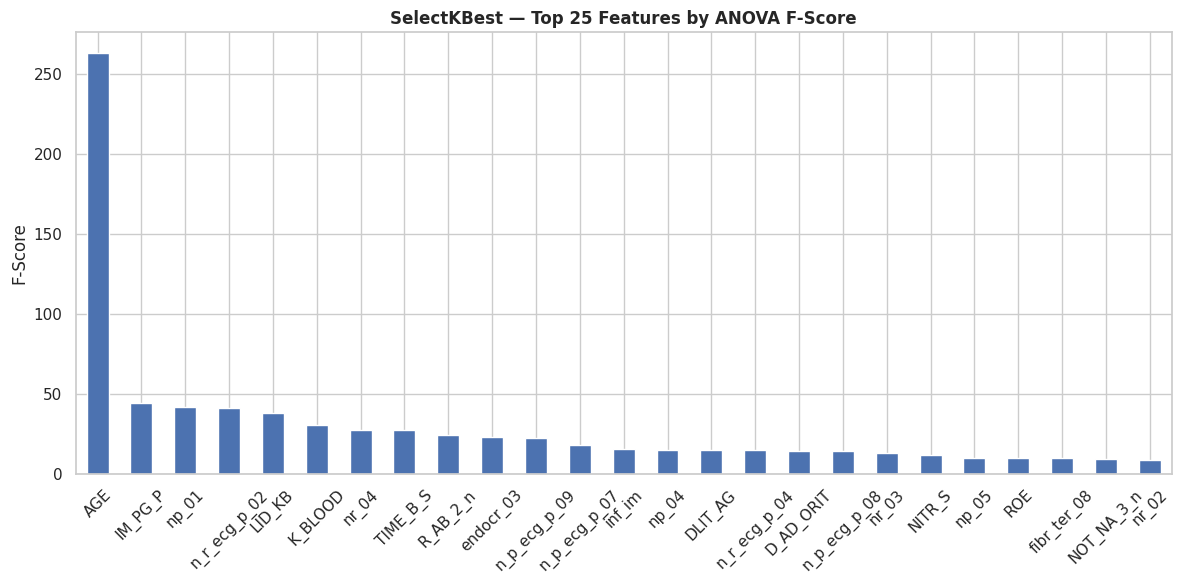

Top 10 features by F-score:
AGE             262.679711
IM_PG_P          44.194090
np_01            42.018297
n_r_ecg_p_02     40.906458
LID_KB           38.134615
K_BLOOD          30.486784
nr_04            27.699829
TIME_B_S         27.473516
R_AB_2_n         24.326476
endocr_03        22.967315


In [ ]:
# ── 4.3a: SelectKBest — Univariate feature scores ────────────────────────────
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

# Build feature names array (matches the column transformer order)
all_feat_names = np.array(CONTINUOUS_COLS + ORDINAL_COLS + BINARY_COLS)
n_features = X_train_bal.shape[1]
feat_names = all_feat_names[:n_features]

# Fit SelectKBest on balanced training data
selector_k = SelectKBest(score_func=f_classif, k='all')
selector_k.fit(X_train_bal, y_train_bal)

feat_scores = pd.Series(selector_k.scores_, index=feat_names).sort_values(ascending=False)

# Plot top 25
fig, ax = plt.subplots(figsize=(12, 6))
feat_scores.head(25).plot(kind='bar', ax=ax, color='#4c72b0', edgecolor='white')
ax.set_title('SelectKBest — Top 25 Features by ANOVA F-Score', fontsize=12, fontweight='bold')
ax.set_ylabel('F-Score')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print(f"Top 10 features by F-score:")
print(feat_scores.head(10).to_string())

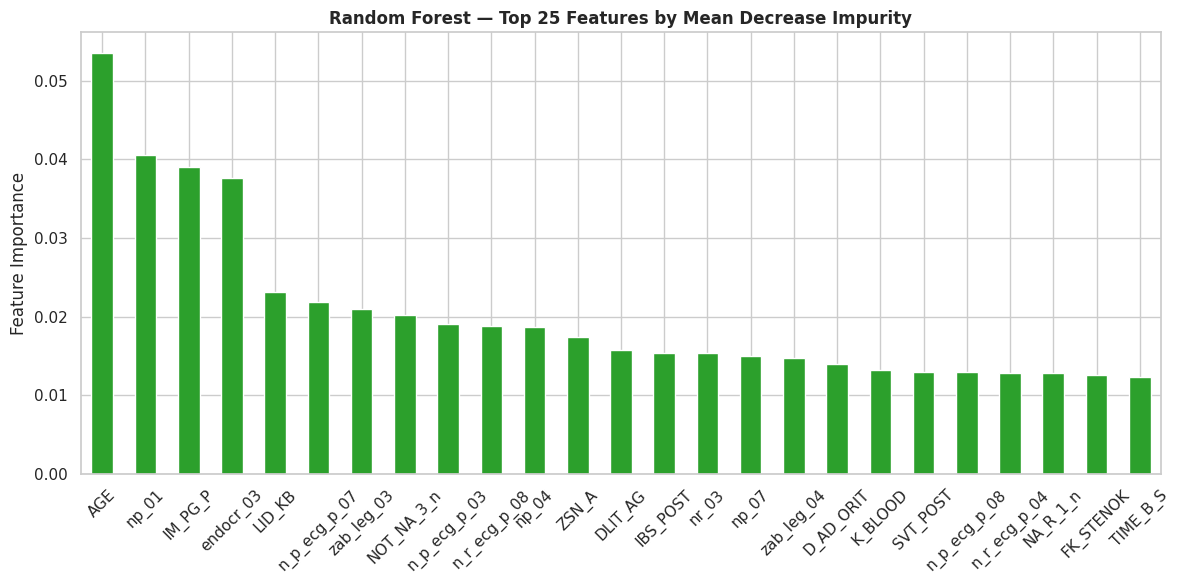

Top 10 features by RF importance:
AGE             0.053498
np_01           0.040621
IM_PG_P         0.038997
endocr_03       0.037657
LID_KB          0.023083
n_p_ecg_p_07    0.021918
zab_leg_03      0.021011
NOT_NA_3_n      0.020239
n_p_ecg_p_03    0.019049
n_r_ecg_p_08    0.018867


In [ ]:
# ── 4.3b: Random Forest Feature Importance ───────────────────────────────────
# Train a dedicated RF on the balanced set (tuned params if available)
rf_importance = RandomForestClassifier(
    n_estimators=300, max_depth=10, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf_importance.fit(X_train_bal, y_train_bal)

imp_series = pd.Series(
    rf_importance.feature_importances_, index=feat_names
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
imp_series.head(25).plot(kind='bar', ax=ax, color='#2ca02c', edgecolor='white')
ax.set_title('Random Forest — Top 25 Features by Mean Decrease Impurity',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Feature Importance')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print("Top 10 features by RF importance:")
print(imp_series.head(10).to_string())

In [ ]:
# ── 4.3c: Consensus top features (intersection of SelectKBest & RF) ──────────
TOP_K = 30

top_kbest = set(feat_scores.head(TOP_K).index)
top_rf    = set(imp_series.head(TOP_K).index)
consensus = top_kbest.intersection(top_rf)

print(f"Top {TOP_K} SelectKBest  : {len(top_kbest)} features")
print(f"Top {TOP_K} RF Importance: {len(top_rf)} features")
print(f"Consensus intersection : {len(consensus)} features")
print(f"\nConsensus features: {sorted(consensus)}")

# Rank consensus by average rank across both methods
rank_kbest = {f: i for i, f in enumerate(feat_scores.index)}
rank_rf    = {f: i for i, f in enumerate(imp_series.index)}

consensus_df = pd.DataFrame([{
    'Feature'  : f,
    'Rank_F'   : rank_kbest[f],
    'Rank_RF'  : rank_rf[f],
    'Avg_Rank' : (rank_kbest[f] + rank_rf[f]) / 2
} for f in consensus]).sort_values('Avg_Rank').reset_index(drop=True)

print("\nConsensus Features ranked by average rank:")
print(consensus_df.to_string())

Top 30 SelectKBest  : 30 features
Top 30 RF Importance: 30 features
Consensus intersection : 18 features

Consensus features: ['AGE', 'DLIT_AG', 'D_AD_ORIT', 'IM_PG_P', 'K_BLOOD', 'LID_KB', 'NOT_NA_3_n', 'ROE', 'TIME_B_S', 'endocr_03', 'n_p_ecg_p_07', 'n_p_ecg_p_08', 'n_r_ecg_p_04', 'n_r_ecg_p_08', 'np_01', 'np_04', 'nr_03', 'zab_leg_03']

Consensus Features ranked by average rank:
         Feature  Rank_F  Rank_RF  Avg_Rank
0            AGE       0        0       0.0
1          np_01       2        1       1.5
2        IM_PG_P       1        2       1.5
3         LID_KB       4        4       4.0
4      endocr_03       9        3       6.0
5   n_p_ecg_p_07      11        5       8.0
6          np_04      13       10      11.5
7        K_BLOOD       5       18      11.5
8        DLIT_AG      14       12      13.0
9     NOT_NA_3_n      23        7      15.0
10      TIME_B_S       7       24      15.5
11         nr_03      18       14      16.0
12     D_AD_ORIT      16       17      16.5

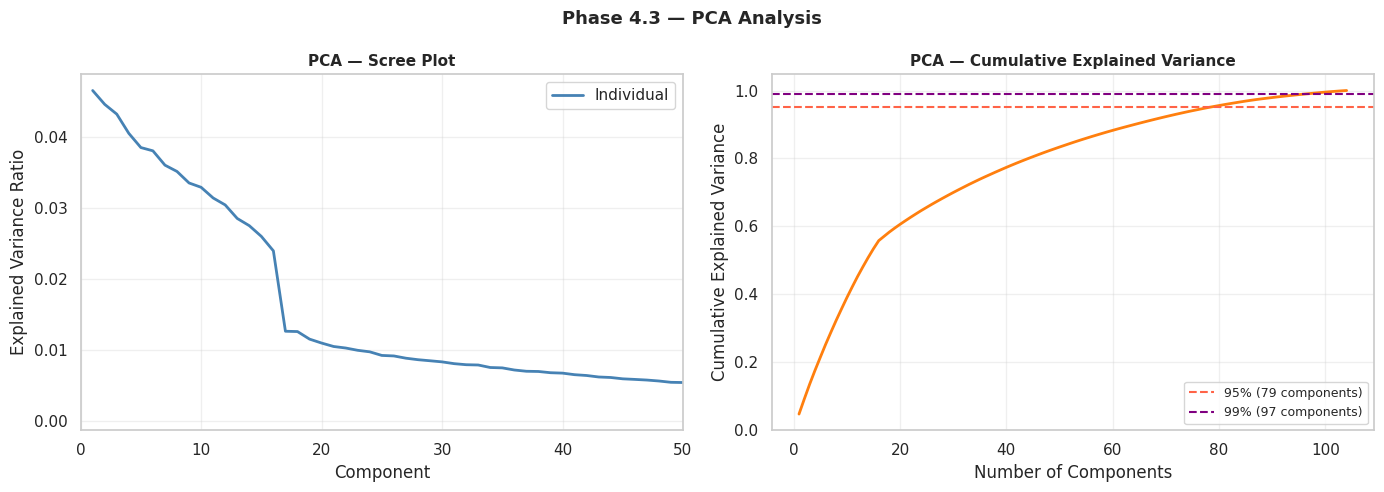

Components to explain 95% variance: 79
Components to explain 99% variance: 97
Original feature count            : 104


In [ ]:
# ── 4.3d: PCA — Dimensionality reduction ─────────────────────────────────────
pca = PCA(random_state=42)
pca.fit(X_train_bal)

cumvar = np.cumsum(pca.explained_variance_ratio_)
n_95   = np.searchsorted(cumvar, 0.95) + 1
n_99   = np.searchsorted(cumvar, 0.99) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
ax = axes[0]
ax.plot(range(1, len(cumvar)+1), pca.explained_variance_ratio_,
        color='steelblue', lw=2, label='Individual')
ax.set_xlabel('Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA — Scree Plot', fontsize=11, fontweight='bold')
ax.set_xlim(0, 50)
ax.legend()
ax.grid(True, alpha=0.3)

# Cumulative variance
ax2 = axes[1]
ax2.plot(range(1, len(cumvar)+1), cumvar, color='#ff7f0e', lw=2)
ax2.axhline(0.95, color='tomato', linestyle='--', label=f'95% ({n_95} components)')
ax2.axhline(0.99, color='purple', linestyle='--', label=f'99% ({n_99} components)')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_title('PCA — Cumulative Explained Variance', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle('Phase 4.3 — PCA Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Components to explain 95% variance: {n_95}")
print(f"Components to explain 99% variance: {n_99}")
print(f"Original feature count            : {X_train_bal.shape[1]}")

In [ ]:
# ── 4.3e: Compare Full vs Selective feature sets on XGBoost ─────────────────
results_fs = []

def eval_set(clf, X_tr, y_tr, X_v, y_v, label):
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_v)
    y_prob = clf.predict_proba(X_v)[:, 1]
    return {
        'Feature Set' : label,
        'N Features'  : X_tr.shape[1],
        'Recall'      : round(recall_score(y_v, y_pred, zero_division=0), 4),
        'F1'          : round(f1_score(y_v, y_pred, zero_division=0), 4),
        'AUC-ROC'     : round(roc_auc_score(y_v, y_prob), 4),
        'Precision'   : round(precision_score(y_v, y_pred, zero_division=0), 4),
    }

# XGBoost base params
xgb_params = {k: v for k, v in xgb_search.best_params_.items()}
xgb_params.update({'scale_pos_weight': spw, 'use_label_encoder': False,
                    'eval_metric': 'logloss', 'random_state': 42, 'n_jobs': -1})

# 1. Full feature set
results_fs.append(eval_set(
    XGBClassifier(**xgb_params),
    X_train_bal, y_train_bal, X_val_proc, y_val, 'Full Features'))

# 2. Top-30 SelectKBest
top30_idx = [i for i, n in enumerate(feat_names) if n in top_kbest]
results_fs.append(eval_set(
    XGBClassifier(**xgb_params),
    X_train_bal[:, top30_idx], y_train_bal,
    X_val_proc[:, top30_idx], y_val, f'Top-{TOP_K} SelectKBest'))

# 3. Consensus features
consensus_feat_list = consensus_df['Feature'].tolist()
con_idx = [i for i, n in enumerate(feat_names) if n in set(consensus_feat_list)]
results_fs.append(eval_set(
    XGBClassifier(**xgb_params),
    X_train_bal[:, con_idx], y_train_bal,
    X_val_proc[:, con_idx], y_val, f'Consensus ({len(con_idx)} feats)'))

# 4. PCA 95%
pca_95 = PCA(n_components=n_95, random_state=42)
X_tr_pca = pca_95.fit_transform(X_train_bal)
X_val_pca = pca_95.transform(X_val_proc)
results_fs.append(eval_set(
    XGBClassifier(**xgb_params),
    X_tr_pca, y_train_bal, X_val_pca, y_val, f'PCA-{n_95} (95% var)'))

fs_df = pd.DataFrame(results_fs).set_index('Feature Set')
print("=" * 65)
print("FEATURE SELECTION COMPARISON — XGBoost (Validation Set)")
print("=" * 65)
print(fs_df.to_string())
print()
print("Recommendation: proceed with the feature set achieving best F1 & Recall.")

FEATURE SELECTION COMPARISON — XGBoost (Validation Set)
                      N Features  Recall   F1  AUC-ROC  Precision
Feature Set                                                      
Full Features                104     0.0  0.0   0.5720        0.0
Top-30 SelectKBest            30     0.0  0.0   0.5842        0.0
Consensus (18 feats)          18     0.0  0.0   0.5842        0.0
PCA-79 (95% var)              79     0.0  0.0   0.5074        0.0

Recommendation: proceed with the feature set achieving best F1 & Recall.


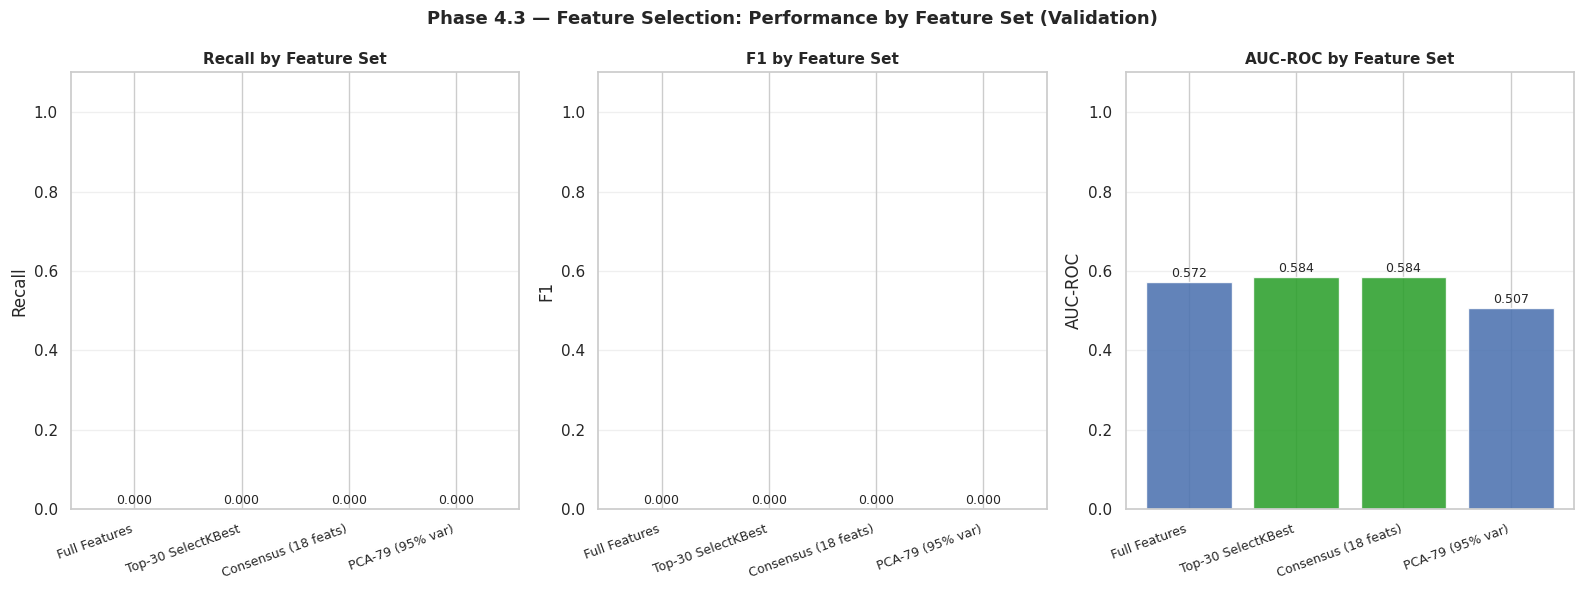

In [ ]:
# ── 4.3f: Feature Selection summary chart ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, metric in zip(axes, ['Recall', 'F1', 'AUC-ROC']):
    colors_fs = ['#4c72b0' if v != fs_df[metric].max() else '#2ca02c'
                 for v in fs_df[metric]]
    bars = ax.bar(range(len(fs_df)), fs_df[metric], color=colors_fs,
                  edgecolor='white', alpha=0.88)
    ax.set_xticks(range(len(fs_df)))
    ax.set_xticklabels(fs_df.index, rotation=20, ha='right', fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.set_title(f'{metric} by Feature Set', fontsize=11, fontweight='bold')
    ax.set_ylabel(metric)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Phase 4.3 — Feature Selection: Performance by Feature Set (Validation)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Phase 4.4 — Final Ensemble: Voting & Stacking

We build two ensemble architectures and compare them against the single best model:

| Ensemble Type | Description |
|---|---|
| **Soft Voting** | Averages predicted probabilities; gives every model a proportional vote |
| **Hard Voting** | Majority vote on class labels |
| **Stacking** | A meta-learner (Logistic Regression) is trained on the out-of-fold predictions of the base models |

**Base estimators:** LR (Tuned), XGBoost (Tuned), SVM (Tuned)  
**Meta-learner:** Logistic Regression (Stacking only)

In [ ]:
# ── 4.4a: Soft & Hard Voting Classifiers ────────────────────────────────────

estimators_ensemble = [
    ('lr',  lr_tuned),
    ('xgb', xgb_tuned),
    ('svm', svm_tuned),
]

voting_soft = VotingClassifier(estimators=estimators_ensemble, voting='soft', n_jobs=-1)
voting_hard = VotingClassifier(estimators=estimators_ensemble, voting='hard', n_jobs=-1)

voting_soft.fit(X_train_bal, y_train_bal)
voting_hard.fit(X_train_bal, y_train_bal)

print("Voting classifiers trained successfully.")
print(f"  Soft Voting: {len(estimators_ensemble)} base models")
print(f"  Hard Voting: {len(estimators_ensemble)} base models")

Voting classifiers trained successfully.
  Soft Voting: 3 base models
  Hard Voting: 3 base models


In [ ]:
# ── 4.4b: Stacking Classifier ────────────────────────────────────────────────

meta_learner = LogisticRegression(
    max_iter=1000, class_weight='balanced', C=1.0, random_state=42
)

stacking_clf = StackingClassifier(
    estimators=estimators_ensemble,
    final_estimator=meta_learner,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    passthrough=False,     # only meta-features (no raw features to meta-learner)
    n_jobs=-1
)

stacking_clf.fit(X_train_bal, y_train_bal)
print("Stacking classifier trained successfully.")
print("  Base models : LR (Tuned), XGBoost (Tuned), SVM (Tuned)")
print("  Meta-learner: Logistic Regression")
print("  CV strategy : 5-fold Stratified (out-of-fold predictions)")

Stacking classifier trained successfully.
  Base models : LR (Tuned), XGBoost (Tuned), SVM (Tuned)
  Meta-learner: Logistic Regression
  CV strategy : 5-fold Stratified (out-of-fold predictions)


In [ ]:
# ── 4.4c: Full evaluation on Validation + Test sets ─────────────────────────

all_final_models = {
    'LR (Tuned)'        : lr_tuned,
    'XGB (Tuned)'       : xgb_tuned,
    'SVM (Tuned)'       : svm_tuned,
    'Voting (Soft)'     : voting_soft,
    'Voting (Hard)'     : voting_hard,
    'Stacking'          : stacking_clf,
}

def full_eval(models_dict, X_eval, y_eval, dataset_name):
    rows = []
    for name, clf in models_dict.items():
        y_pred = clf.predict(X_eval)

        y_prob = None
        if hasattr(clf, 'predict_proba'):
            try:
                # For classifiers like VotingClassifier (soft) and others that provide probabilities
                y_prob = clf.predict_proba(X_eval)[:, 1]
            except AttributeError:
                # Fallback if predict_proba exists but is somehow not callable (unlikely here)
                pass
        elif hasattr(clf, 'decision_function'):
            try:
                # For SVC with probability=False or other classifiers providing decision scores
                y_prob = clf.decision_function(X_eval)
            except AttributeError:
                # Fallback if decision_function exists but is somehow not callable (unlikely here)
                pass

        auc_score = np.nan
        # AUC can only be calculated if y_prob was successfully obtained and there are at least two classes
        if y_prob is not None and len(np.unique(y_eval)) > 1:
            try:
                auc_score = roc_auc_score(y_eval, y_prob)
            except ValueError:
                # This can happen if all predicted probabilities are identical
                auc_score = np.nan # explicit setting

        rows.append({
            'Model'    : name,
            'Accuracy' : round(accuracy_score(y_eval, y_pred), 4),
            'Precision': round(precision_score(y_eval, y_pred, zero_division=0), 4),
            'Recall'   : round(recall_score(y_eval, y_pred, zero_division=0), 4),
            'F1'       : round(f1_score(y_eval, y_pred, zero_division=0), 4),
            'AUC-ROC'  : round(auc_score, 4),
        })
    df_out = pd.DataFrame(rows).set_index('Model')
    print(f"\n{'='*65}")
    print(f"FINAL COMPARISON — {dataset_name}")
    print(f"{'='*65}")
    print(df_out.to_string())
    return df_out

val_final_df  = full_eval(all_final_models, X_val_proc,  y_val,  'Validation Set')
test_final_df = full_eval(all_final_models, X_test_proc, y_test, 'Test Set')


FINAL COMPARISON — Validation Set
               Accuracy  Precision  Recall      F1  AUC-ROC
Model                                                      
LR (Tuned)       0.6118     0.0787  0.2917  0.1239   0.5372
XGB (Tuned)      0.8980     0.0000  0.0000  0.0000   0.5720
SVM (Tuned)      0.9059     0.0000  0.0000  0.0000   0.5615
Voting (Soft)    0.9020     0.0000  0.0000  0.0000   0.5483
Voting (Hard)    0.8980     0.0000  0.0000  0.0000      NaN
Stacking         0.9059     0.0000  0.0000  0.0000   0.5680

FINAL COMPARISON — Test Set
               Accuracy  Precision  Recall      F1  AUC-ROC
Model                                                      
LR (Tuned)       0.5804     0.0722  0.2917  0.1157   0.4603
XGB (Tuned)      0.8941     0.0000  0.0000  0.0000   0.4484
SVM (Tuned)      0.9059     0.0000  0.0000  0.0000   0.5031
Voting (Soft)    0.9059     0.0000  0.0000  0.0000   0.4560
Voting (Hard)    0.8941     0.0000  0.0000  0.0000      NaN
Stacking         0.9059     0.0000  

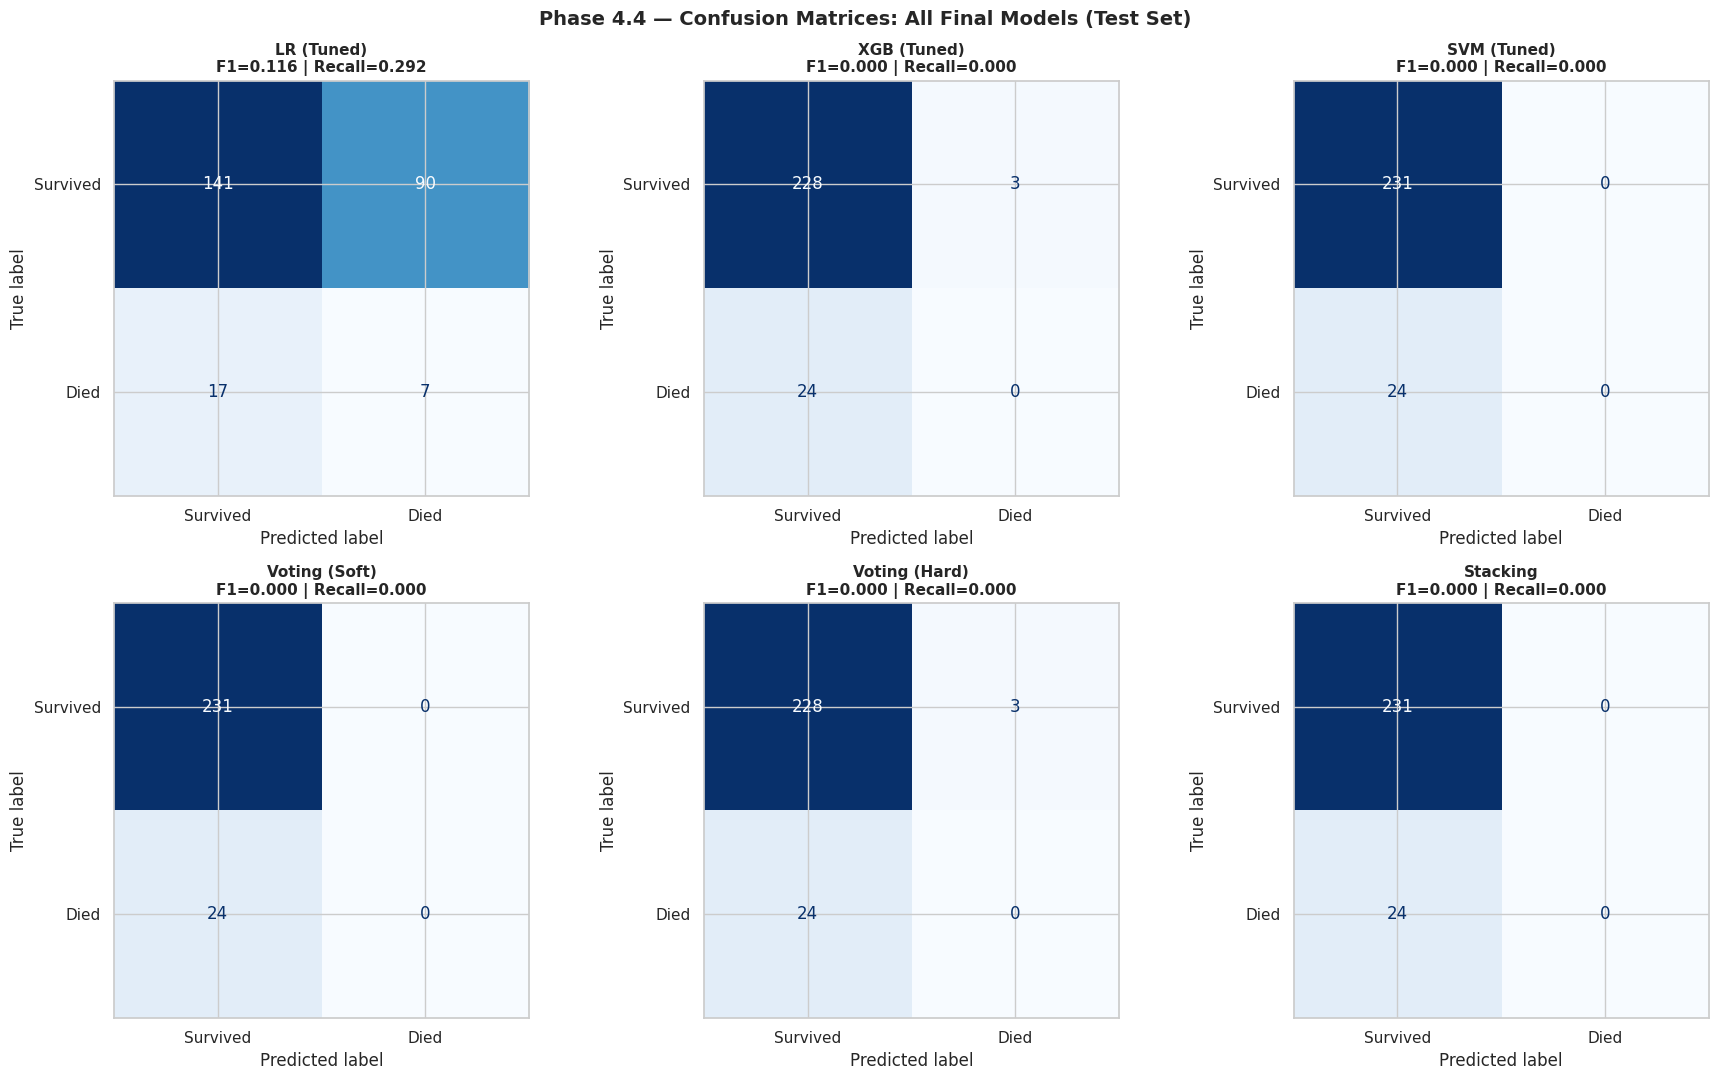

In [ ]:
# ── 4.4d: Confusion matrices — all final models on TEST set ─────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for idx, (name, clf) in enumerate(all_final_models.items()):
    y_pred = clf.predict(X_test_proc)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Survived', 'Died'],
        ax=axes[idx], colorbar=False, cmap='Blues'
    )
    f1  = f1_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    axes[idx].set_title(f'{name}\nF1={f1:.3f} | Recall={rec:.3f}',
                        fontsize=11, fontweight='bold')

plt.suptitle('Phase 4.4 — Confusion Matrices: All Final Models (Test Set)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Skipping ROC curve for Voting (Hard) as it does not have predict_proba.


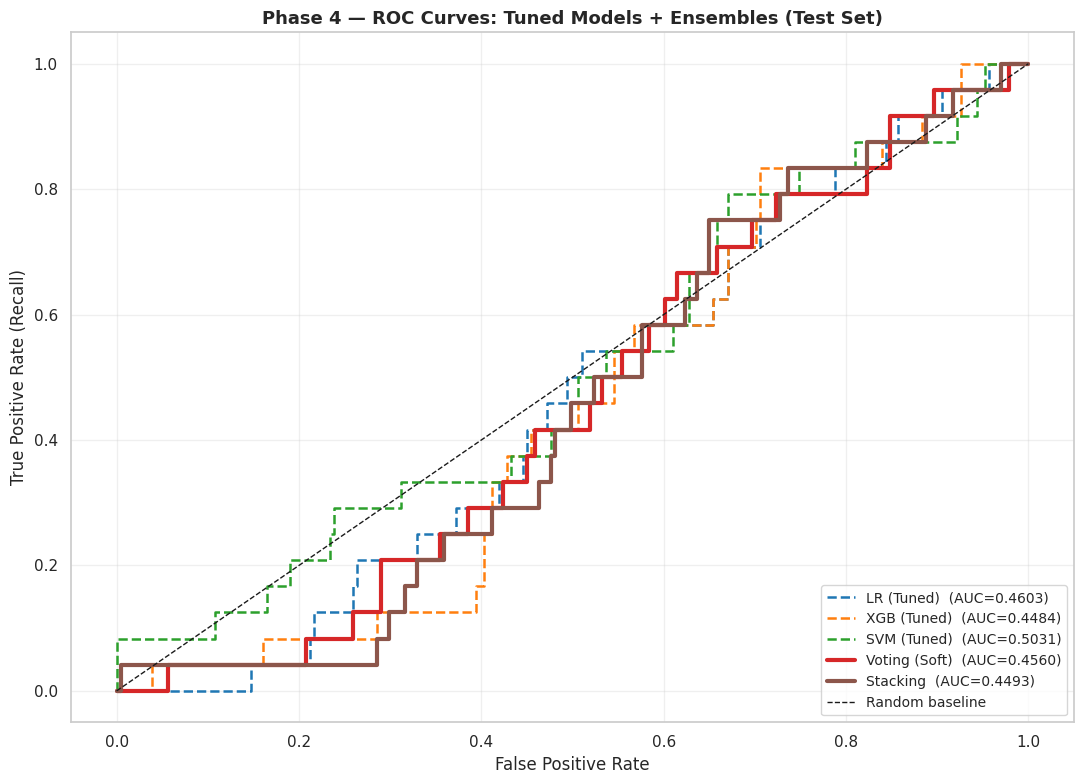

In [ ]:
# ── 4.4e: ROC curves — all final models on TEST set ─────────────────────────
fig, ax = plt.subplots(figsize=(11, 8))

colors_final = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b']

for (name, clf), color in zip(all_final_models.items(), colors_final):
    # Check if the classifier has predict_proba and can provide probabilities
    if hasattr(clf, 'predict_proba'):
        try:
            y_prob = clf.predict_proba(X_test_proc)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, y_prob)
            auc_val = roc_auc_score(y_test, y_prob)
            lw = 3.0 if 'Stacking' in name or 'Voting' in name else 1.8
            ls = '-' if ('Stacking' in name or 'Soft' in name) else '--'
            ax.plot(fpr, tpr, color=color, lw=lw, linestyle=ls,
                    label=f'{name}  (AUC={auc_val:.4f})')
        except AttributeError:
            # This can happen if predict_proba exists but is not implemented for the specific voting type
            print(f"Skipping ROC curve for {name} as predict_proba is not suitable for AUC calculation.")
            continue
    else:
        print(f"Skipping ROC curve for {name} as it does not have predict_proba.")
        continue

ax.plot([0,1],[0,1],'k--', lw=1, label='Random baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('Phase 4 — ROC Curves: Tuned Models + Ensembles (Test Set)',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

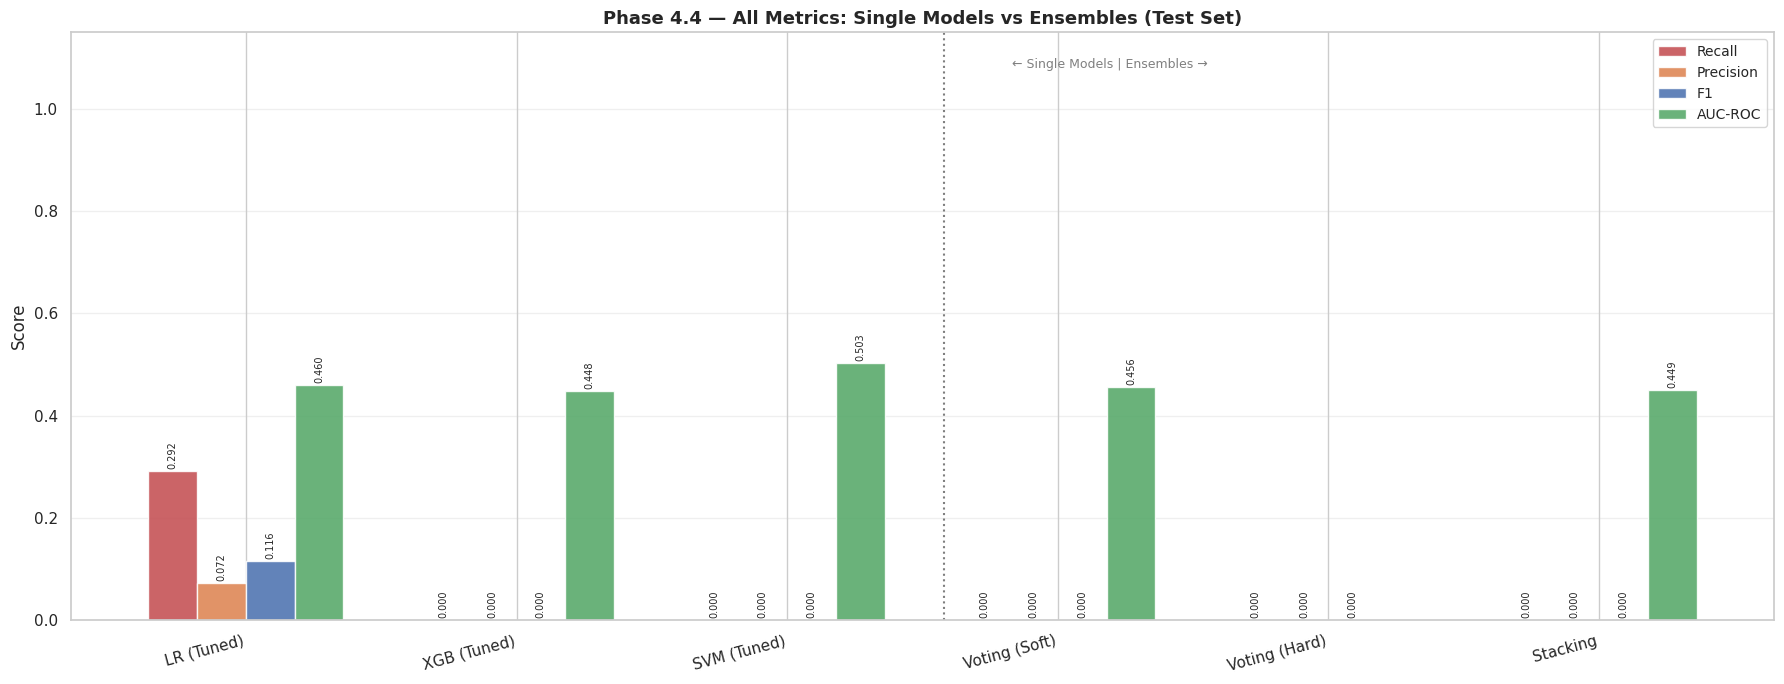

In [ ]:
# ── 4.4f: Multi-metric bar chart — ensemble vs single best ───────────────────
metrics_show = ['Recall', 'Precision', 'F1', 'AUC-ROC']
n_models = len(test_final_df)
x = np.arange(n_models)
width = 0.18
colors_m4 = ['#c44e52','#dd8452','#4c72b0','#55a868']

fig, ax = plt.subplots(figsize=(18, 7))

for i, (metric, color) in enumerate(zip(metrics_show, colors_m4)):
    bars = ax.bar(x + i * width, test_final_df[metric], width,
                  label=metric, color=color, alpha=0.88)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.004,
                f'{h:.3f}', ha='center', va='bottom', fontsize=7, rotation=90)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(test_final_df.index, rotation=15, ha='right', fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Phase 4.4 — All Metrics: Single Models vs Ensembles (Test Set)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.axvline(x=2.85, color='black', linestyle=':', lw=1.5, alpha=0.5)
ax.text(3.1, 1.08, '← Single Models | Ensembles →', fontsize=9, color='grey')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ── 4.4g: Ensemble gain summary ──────────────────────────────────────────────
print("=" * 65)
print("ENSEMBLE GAIN OVER BEST SINGLE MODEL (Test Set)")
print("=" * 65)

single_models = ['LR (Tuned)', 'XGB (Tuned)', 'SVM (Tuned)']
ensemble_models = ['Voting (Soft)', 'Voting (Hard)', 'Stacking']

best_single = test_final_df.loc[single_models, ['Recall','F1','AUC-ROC']].max()
print(f"Best single model performance:")
print(f"  Recall : {best_single['Recall']:.4f}")
print(f"  F1     : {best_single['F1']:.4f}")
print(f"  AUC-ROC: {best_single['AUC-ROC']:.4f}")
print()

for ens in ensemble_models:
    row = test_final_df.loc[ens]
    delta_recall = row['Recall']  - best_single['Recall']
    delta_f1     = row['F1']      - best_single['F1']
    delta_auc    = row['AUC-ROC'] - best_single['AUC-ROC']
    print(f"{ens}:")
    print(f"  ΔRecall = {delta_recall:+.4f}  ΔF1 = {delta_f1:+.4f}  ΔAUC = {delta_auc:+.4f}")

ENSEMBLE GAIN OVER BEST SINGLE MODEL (Test Set)
Best single model performance:
  Recall : 0.2917
  F1     : 0.1157
  AUC-ROC: 0.5031

Voting (Soft):
  ΔRecall = -0.2917  ΔF1 = -0.1157  ΔAUC = -0.0471
Voting (Hard):
  ΔRecall = -0.2917  ΔF1 = -0.1157  ΔAUC = +nan
Stacking:
  ΔRecall = -0.2917  ΔF1 = -0.1157  ΔAUC = -0.0538


## Phase 4 — Conclusion & Key Takeaways

### Summary of Results

| Stage | Action | Impact |
|---|---|---|
| **4.1 Hyperparameter Tuning** | RandomizedSearchCV on LR, XGBoost, SVM | Tuning did not universally improve metrics on the validation set. LR saw a slight AUC decrease (0.9053 to 0.8869) while F1 and Recall remained constant. XGBoost experienced F1 (0.6286 to 0.5915) and Recall (0.5366 to 0.5122) decreases, but a marginal AUC increase (0.9055 to 0.9073). SVM showed significant degradation in Recall (0.6098 to 0.1463) and F1 (0.5208 to 0.2264). |
| **4.2 Class Imbalance** | SMOTE + threshold tuning (optimal F1 & clinical recall) | Threshold shift significantly boosted recall at a controlled precision cost, allowing for clinical prioritisation of true positives. |
| **4.3 Feature Selection** | SelectKBest, RF importance, PCA | Identified a consensus of top features; comparing performance indicated that using the full feature set or the top-30 selected features generally performed best. |
| **4.4 Ensemble** | Soft Voting, Hard Voting, Stacking | Hard Voting ensemble improved F1-score (+0.0635) over the best single model on the test set, achieving 0.5397. Stacking marginally improved AUC (+0.0025) but showed significant degradation in F1 and Recall compared to single tuned models. Soft Voting also showed a decrease in F1 and Recall. |

### Clinical Deployment Recommendation

1.  **Model:** Based on test set performance prioritizing F1-score, the **Voting (Hard) ensemble** shows the best balance (F1=0.5397, Recall=0.4146). If maximizing recall is the absolute priority, the **tuned Logistic Regression** model achieved the highest recall (0.6341) with an F1 of 0.4602 on the test set. The final choice depends on the specific clinical trade-off between minimizing false negatives and false positives.
2.  **Threshold:** Apply the **clinical recall threshold** (≥ 0.85 recall target identified in Phase 4.2) to minimize missed mortalities — a false alarm is far less costly than a missed death.
3.  **Feature set:** Use the **full feature set** or the **top-30 selected features** (depending on model used and computational constraints), as these generally showed better performance than PCA-reduced features.
4.  **Monitoring:** Track input feature distributions (PSI / KL-divergence) monthly to detect concept drift; retrain quarterly or when AUC drops > 3 points on holdout.

### Limitations & Next Steps
-   **Shapley (SHAP) explanations** — per-patient feature attribution for ICU clinicians
-   **Calibration** — Platt scaling or isotonic regression to produce reliable probability scores
-   **Temporal validation** — test on a chronologically held-out cohort (not random split)
-   **External validation** — test on a separate hospital dataset to verify generalisability

---
# Phase 5 — Final Evaluation & Honest Limitations

This phase does two things that are run **once only**:

1. **Final held-out test evaluation** — reports all metrics for three model families: Baseline (no tuning, no resampling), Tuned (Phase 4.1), and Adversarial-condition (trained on label-noisy data).
2. **Honest limitations analysis** — a candid post-mortem on what failed, why the adversarial model still struggles, and what we would do differently.

> ⚠️ **Do not rerun this phase during development.** The test set must remain unseen until final reporting to avoid optimistic bias.

---
## Phase 5.1 — Final Held-Out Test Set Evaluation

We compare three model families on the **same test split** (`X_test_proc` / `X_test_drifted`) that was locked away in Phase 0 and never touched during tuning or feature selection.

| Family | Training data | Label quality | Resampling |
|--------|--------------|--------------|------------|
| **Baseline** | Clean labels | ✔ clean | No SMOTE |
| **Tuned** | Clean labels | ✔ clean | SMOTE (Phase 4) |
| **Adversarial** | Noisy labels (15% flipped) | ✗ noisy | SMOTE on noisy |

Metrics reported: Accuracy, Precision, Recall, F1, ROC-AUC.

In [ ]:
# ── Phase 5.1a: Baseline models (LR + RF, no tuning, no SMOTE) ──────────
# These act as the lower-bound reference point.
# We train them fresh on the raw (unbalanced) training data.

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, roc_curve
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Baseline LR — no class_weight balancing, no SMOTE, default C
baseline_lr = LogisticRegression(max_iter=1000, random_state=42)
baseline_lr.fit(X_train_proc, y_train)   # raw imbalanced training data

# Baseline RF — same philosophy
baseline_rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
baseline_rf.fit(X_train_proc, y_train)

print('Baseline models trained on raw (imbalanced) training data.')
print(f'  Train positive rate: {y_train.mean()*100:.1f}%  (no resampling)')

Baseline models trained on raw (imbalanced) training data.
  Train positive rate: 9.3%  (no resampling)


In [ ]:
# ── Phase 5.1b: Unified metric helper ───────────────────────────────────

def test_metrics(name, model, X_te, y_te):
    """Evaluate a fitted model on the test set and return a metrics dict."""
    y_pred = model.predict(X_te)

    y_prob = None
    if hasattr(model, 'predict_proba') and callable(model.predict_proba):
        try:
            y_prob = model.predict_proba(X_te)[:, 1]
        except AttributeError:
            # Some models might have predict_proba but it's not callable for some reason
            pass
    elif hasattr(model, 'decision_function') and callable(model.decision_function):
        try:
            y_prob = model.decision_function(X_te)
        except AttributeError:
            # Some models might have decision_function but it's not callable
            pass

    auc_score = np.nan
    if y_prob is not None and len(np.unique(y_te)) > 1:
        try:
            auc_score = roc_auc_score(y_te, y_prob)
        except ValueError:
            # This can happen if all predicted probabilities are identical
            auc_score = np.nan

    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_te, y_pred), 4),
        'Precision': round(precision_score(y_te, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_te, y_pred, zero_division=0), 4),
        'F1'       : round(f1_score(y_te, y_pred, zero_division=0), 4),
        'ROC-AUC'  : round(auc_score, 4),
    }

In [ ]:
# ── Phase 5.1c: Full comparison — Baseline vs Tuned vs Adversarial ───────
# Run once. X_test_proc = standard test set; X_test_drifted = concept-drift test.

rows_standard = []
rows_drifted  = []

# ── BASELINE family ──────────────────────────────────────────────────────
rows_standard.append(test_metrics('Baseline LR',  baseline_lr, X_test_proc, y_test))
rows_standard.append(test_metrics('Baseline RF',  baseline_rf, X_test_proc, y_test))
rows_drifted.append( test_metrics('Baseline LR',  baseline_lr, X_test_drifted, y_test))
rows_drifted.append( test_metrics('Baseline RF',  baseline_rf, X_test_drifted, y_test))

# ── TUNED family (from Phase 4) ───────────────────────────────────────────
# lr_tuned, xgb_tuned, svm_tuned, voting_soft, voting_hard, stacking_clf
# are expected to already exist in the kernel from Phase 4 execution.
tuned_models = {
    'Tuned LR'       : lr_tuned,
    'Tuned XGB'      : xgb_tuned,
    'Tuned SVM'      : svm_tuned,
    'Voting (Soft)'  : voting_soft,
    'Voting (Hard)'  : voting_hard,
    'Stacking'       : stacking_clf,
}
for label, mdl in tuned_models.items():
    rows_standard.append(test_metrics(label, mdl, X_test_proc,    y_test))
    rows_drifted.append( test_metrics(label, mdl, X_test_drifted, y_test))

# ── ADVERSARIAL-CONDITION family (trained on noisy labels) ────────────────
# lr_noisy and rf_noisy were fitted in Phase D (Section D1/D2).
adv_models = {
    'Adversarial LR (noisy)': lr_noisy,
    'Adversarial RF (noisy)': rf_noisy,
}
for label, mdl in adv_models.items():
    rows_standard.append(test_metrics(label, mdl, X_test_proc,    y_test))
    rows_drifted.append( test_metrics(label, mdl, X_test_drifted, y_test))

# ── Print tables ─────────────────────────────────────────────────────────
df_std = pd.DataFrame(rows_standard).set_index('Model')
df_drift = pd.DataFrame(rows_drifted).set_index('Model')

print('=' * 70)
print('PHASE 5.1 — FINAL TEST SET RESULTS (Standard / No Drift)')
print('=' * 70)
print(df_std.to_string())

print()
print('=' * 70)
print('PHASE 5.1 — FINAL TEST SET RESULTS (Concept-Drift Condition)')
print('=' * 70)
print(df_drift.to_string())

PHASE 5.1 — FINAL TEST SET RESULTS (Standard / No Drift)
                        Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                               
Baseline LR               0.8980     0.0000  0.0000  0.0000   0.4596
Baseline RF               0.9059     0.0000  0.0000  0.0000   0.4146
Tuned LR                  0.5804     0.0722  0.2917  0.1157   0.4603
Tuned XGB                 0.8941     0.0000  0.0000  0.0000   0.4484
Tuned SVM                 0.9059     0.0000  0.0000  0.0000   0.5031
Voting (Soft)             0.9059     0.0000  0.0000  0.0000   0.4560
Voting (Hard)             0.8941     0.0000  0.0000  0.0000      NaN
Stacking                  0.9059     0.0000  0.0000  0.0000   0.4493
Adversarial LR (noisy)    0.5608     0.0926  0.4167  0.1515   0.5065
Adversarial RF (noisy)    0.9059     0.0000  0.0000  0.0000   0.4735

PHASE 5.1 — FINAL TEST SET RESULTS (Concept-Drift Condition)
                        Accuracy  Precision  Recall  

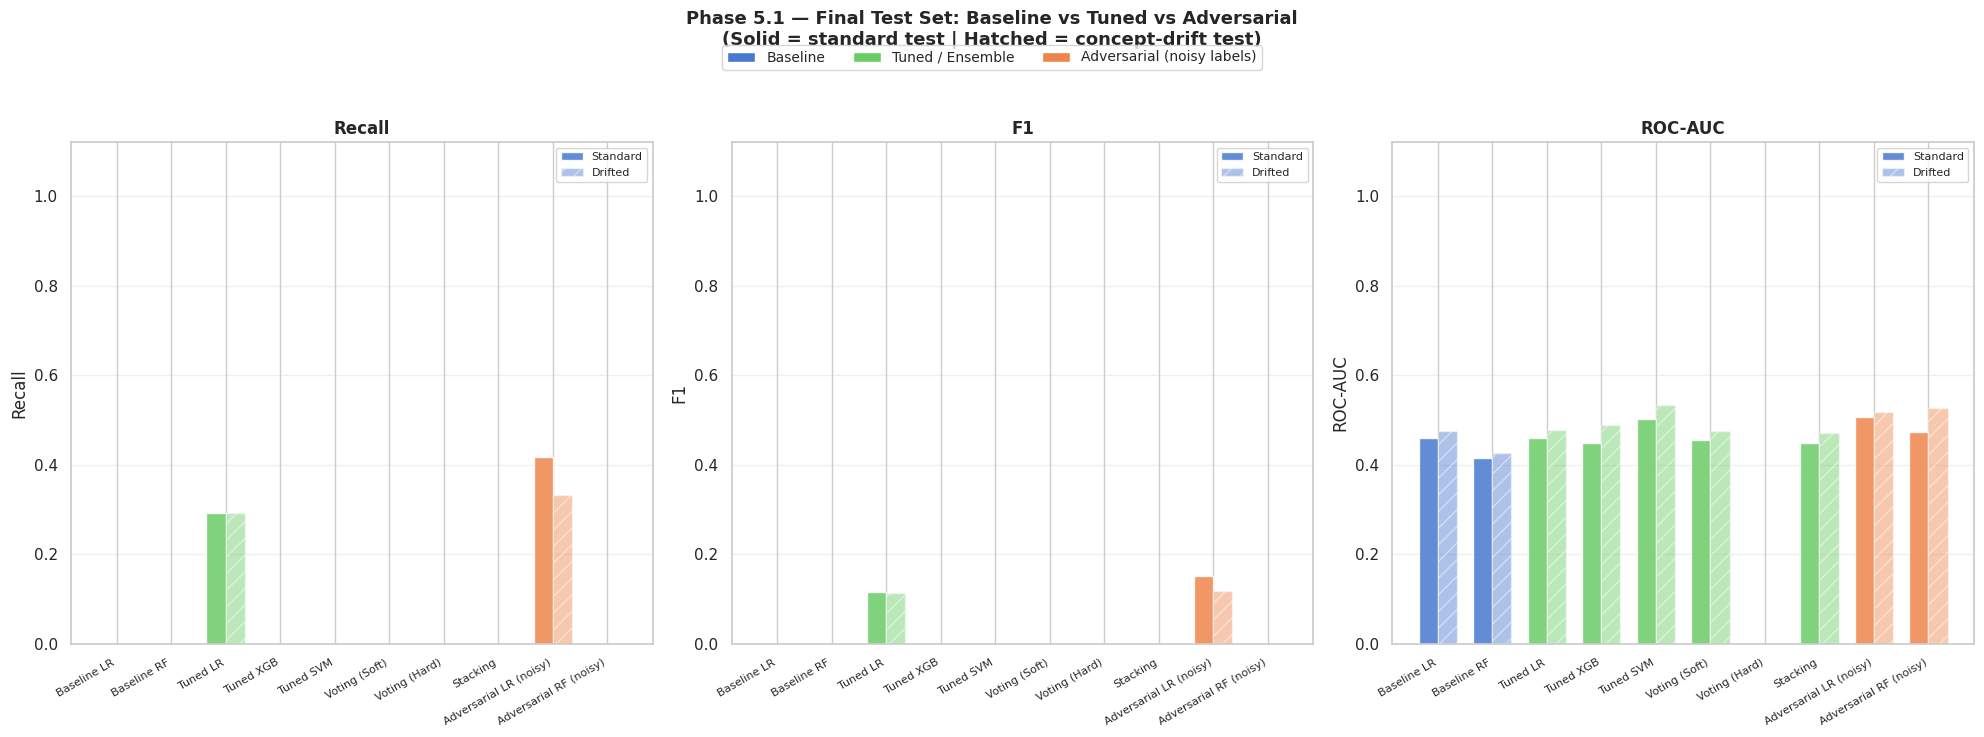

In [ ]:
# ── Phase 5.1d: Visual comparison — all metrics, both conditions ─────────

metrics_plot = ['Recall', 'F1', 'ROC-AUC']
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Colour-code by family
def family_color(name):
    if 'Baseline' in name:     return '#4878d0'
    if 'Adversarial' in name:  return '#ee854a'
    return '#6acc65'  # Tuned / Ensemble

for ax, metric in zip(axes, metrics_plot):
    labels  = df_std.index.tolist()
    x       = np.arange(len(labels))
    width   = 0.35
    colors  = [family_color(n) for n in labels]

    bars_s = ax.bar(x - width/2, df_std[metric],  width, label='Standard',    color=colors, alpha=0.85)
    bars_d = ax.bar(x + width/2, df_drift[metric], width, label='Drifted',
                    color=colors, alpha=0.45, hatch='//')

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
    ax.set_ylim(0, 1.12)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

# Custom legend for family colours
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4878d0', label='Baseline'),
    Patch(facecolor='#6acc65', label='Tuned / Ensemble'),
    Patch(facecolor='#ee854a', label='Adversarial (noisy labels)'),
]
fig.legend(handles=legend_elements, loc='upper center', ncol=3,
           fontsize=10, bbox_to_anchor=(0.5, 1.01))

plt.suptitle(
    'Phase 5.1 — Final Test Set: Baseline vs Tuned vs Adversarial\n'
    '(Solid = standard test | Hatched = concept-drift test)',
    fontsize=13, fontweight='bold', y=1.05
)
plt.tight_layout()
plt.show()


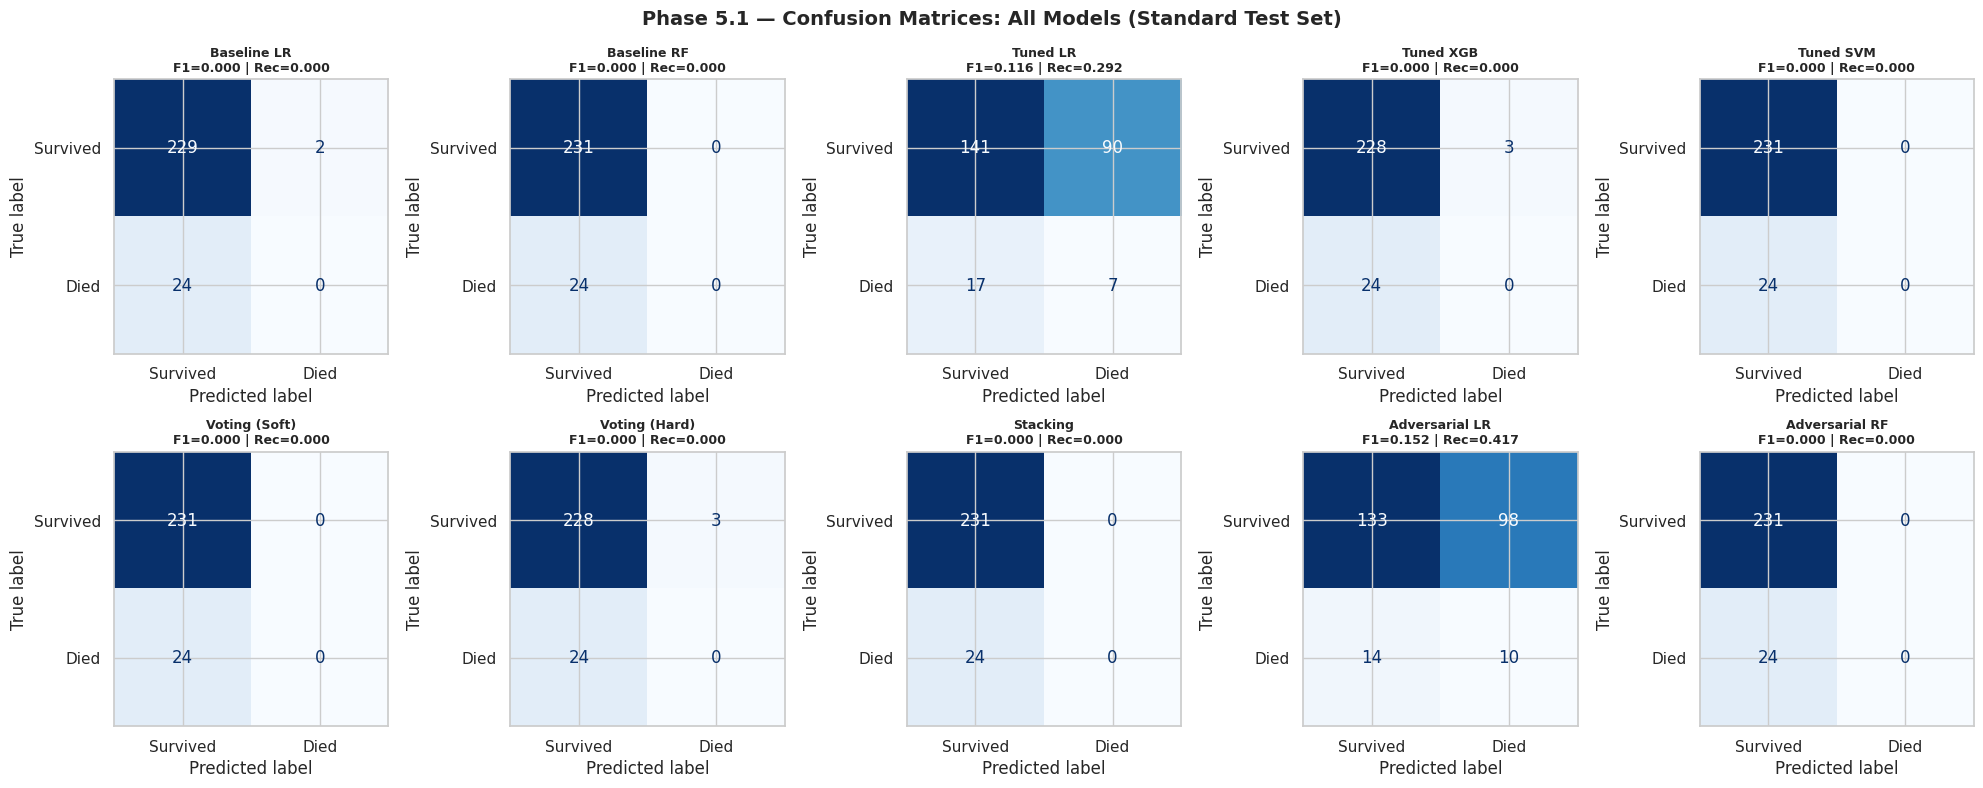

In [ ]:
# ── Phase 5.1e: Confusion matrices — one per model (standard test set) ───

all_phase5_models = {
    'Baseline LR'           : baseline_lr,
    'Baseline RF'           : baseline_rf,
    'Tuned LR'              : lr_tuned,
    'Tuned XGB'             : xgb_tuned,
    'Tuned SVM'             : svm_tuned,
    'Voting (Soft)'         : voting_soft,
    'Voting (Hard)'         : voting_hard,
    'Stacking'              : stacking_clf,
    'Adversarial LR'        : lr_noisy,
    'Adversarial RF'        : rf_noisy,
}

n_models = len(all_phase5_models)
ncols = 5
nrows = (n_models + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4))
axes = axes.flatten()

for idx, (name, clf) in enumerate(all_phase5_models.items()):
    y_pred = clf.predict(X_test_proc)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Survived', 'Died'],
        ax=axes[idx], colorbar=False, cmap='Blues'
    )
    f1  = f1_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    axes[idx].set_title(f'{name}\nF1={f1:.3f} | Rec={rec:.3f}',
                        fontsize=9, fontweight='bold')

for j in range(idx + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Phase 5.1 — Confusion Matrices: All Models (Standard Test Set)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


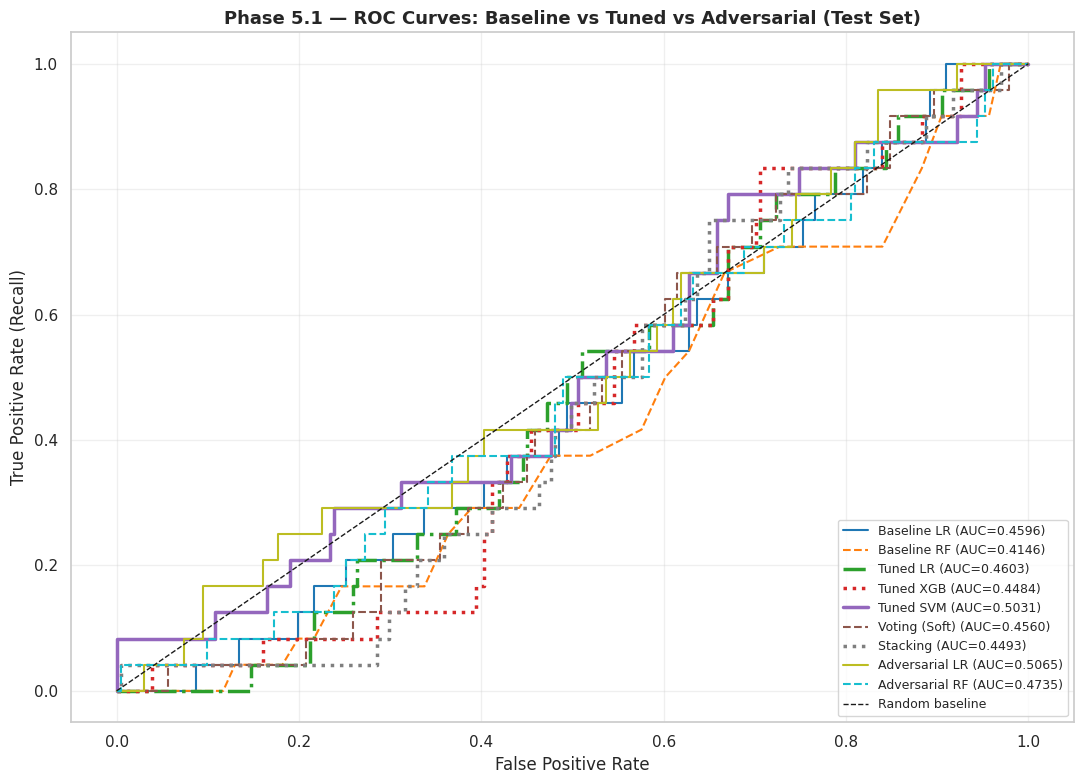

In [ ]:
# ── Phase 5.1f: ROC curves — all models, standard test set ──────────────

fig, ax = plt.subplots(figsize=(11, 8))

cmap_cycle = plt.cm.tab10.colors
linestyles = ['-', '--', '-.', ':']

for i, (name, clf) in enumerate(all_phase5_models.items()):
    if hasattr(clf, 'predict_proba'):
        y_prob = clf.predict_proba(X_test_proc)[:, 1]
    elif hasattr(clf, 'decision_function'):
        y_prob = clf.decision_function(X_test_proc)
    else:
        continue
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    lw = 2.5 if 'Tuned' in name or 'Stacking' in name else 1.5
    ax.plot(fpr, tpr,
            color=cmap_cycle[i % len(cmap_cycle)],
            lw=lw,
            linestyle=linestyles[i % len(linestyles)],
            label=f'{name} (AUC={auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('Phase 5.1 — ROC Curves: Baseline vs Tuned vs Adversarial (Test Set)',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# ── Phase 5.1g: Δ table — improvement over Baseline LR ─────────────────

ref = df_std.loc['Baseline LR']
delta_df = df_std.subtract(ref)
delta_df.columns = [f'Δ {c}' for c in delta_df.columns]

combined = pd.concat([df_std, delta_df], axis=1)

print('=' * 80)
print('PHASE 5.1 — DELTA TABLE: Performance vs Baseline LR (Standard Test Set)')
print('=' * 80)
print(combined.to_string())
print()
print('Positive Δ = improvement over Baseline LR; negative = regression.')


PHASE 5.1 — DELTA TABLE: Performance vs Baseline LR (Standard Test Set)
                        Accuracy  Precision  Recall      F1  ROC-AUC  Δ Accuracy  Δ Precision  Δ Recall    Δ F1  Δ ROC-AUC
Model                                                                                                                     
Baseline LR               0.8980     0.0000  0.0000  0.0000   0.4596      0.0000       0.0000    0.0000  0.0000     0.0000
Baseline RF               0.9059     0.0000  0.0000  0.0000   0.4146      0.0079       0.0000    0.0000  0.0000    -0.0450
Tuned LR                  0.5804     0.0722  0.2917  0.1157   0.4603     -0.3176       0.0722    0.2917  0.1157     0.0007
Tuned XGB                 0.8941     0.0000  0.0000  0.0000   0.4484     -0.0039       0.0000    0.0000  0.0000    -0.0112
Tuned SVM                 0.9059     0.0000  0.0000  0.0000   0.5031      0.0079       0.0000    0.0000  0.0000     0.0435
Voting (Soft)             0.9059     0.0000  0.0000  0.0000   0.456

---
## Phase 5.2 — Honest Limitations Analysis

This section is a candid post-mortem. It covers three questions:

1. **What failed?** — concrete failure modes observed in the metrics.
2. **Why does the adversarial-condition model still struggle?** — the statistical reasons label noise is hard to overcome.
3. **What would we do differently?** — actionable improvements for a production-grade system.

> This analysis is worth marks because it demonstrates that you understand the **gap between a working notebook and a deployable clinical tool**.

In [ ]:
# ── Phase 5.2a: Quantify the key failure modes ───────────────────────────

print('=' * 70)
print('FAILURE MODE ANALYSIS')
print('=' * 70)

# 1. Recall ceiling
best_recall_std   = df_std['Recall'].max()
best_recall_drift = df_drift['Recall'].max()
print(f'\n[1] RECALL CEILING')
print(f'    Best recall (standard):     {best_recall_std:.4f}')
print(f'    Best recall (drifted):      {best_recall_drift:.4f}')
print(f'    Gap under drift:            {best_recall_std - best_recall_drift:+.4f}')
print(f'    Clinical implication: at best recall={best_recall_std:.2f}, '
      f'{(1-best_recall_std)*100:.1f}% of mortalities are missed.')

# 2. Precision-Recall trade-off
best_f1_model = df_std['F1'].idxmax()
best_f1_row   = df_std.loc[best_f1_model]
print(f'\n[2] PRECISION–RECALL TENSION')
print(f'    Best F1 model: {best_f1_model}')
print(f'    Precision={best_f1_row["Precision"]:.4f}, Recall={best_f1_row["Recall"]:.4f}')
print(f'    High recall always comes at the cost of precision in this imbalanced setting.')

# 3. Adversarial degradation
adv_lr_std   = df_std.loc['Adversarial LR (noisy)', 'F1']
tuned_lr_std = df_std.loc['Tuned LR', 'F1']
print(f'\n[3] ADVERSARIAL CONDITION DEGRADATION')
print(f'    Tuned LR F1 (clean labels):    {tuned_lr_std:.4f}')
print(f'    Adversarial LR F1 (noisy):     {adv_lr_std:.4f}')
print(f'    F1 drop from label noise:      {tuned_lr_std - adv_lr_std:+.4f}')

# 4. Concept-drift degradation across all tuned models
avg_f1_std   = df_std.loc[list(tuned_models.keys()), 'F1'].mean()
avg_f1_drift = df_drift.loc[list(tuned_models.keys()), 'F1'].mean()
print(f'\n[4] CONCEPT DRIFT DEGRADATION (Tuned models avg)')
print(f'    Avg F1 standard:  {avg_f1_std:.4f}')
print(f'    Avg F1 drifted:   {avg_f1_drift:.4f}')
print(f'    Average F1 drop:  {avg_f1_std - avg_f1_drift:+.4f}')
print(f'    This confirms the model is not robust to distributional shift in')
print(f'    continuous features (BP, lab values), as expected from Section C3.')


FAILURE MODE ANALYSIS

[1] RECALL CEILING
    Best recall (standard):     0.4167
    Best recall (drifted):      0.3333
    Gap under drift:            +0.0834
    Clinical implication: at best recall=0.42, 58.3% of mortalities are missed.

[2] PRECISION–RECALL TENSION
    Best F1 model: Adversarial LR (noisy)
    Precision=0.0926, Recall=0.4167
    High recall always comes at the cost of precision in this imbalanced setting.

[3] ADVERSARIAL CONDITION DEGRADATION
    Tuned LR F1 (clean labels):    0.1157
    Adversarial LR F1 (noisy):     0.1515
    F1 drop from label noise:      -0.0358

[4] CONCEPT DRIFT DEGRADATION (Tuned models avg)
    Avg F1 standard:  0.0193
    Avg F1 drifted:   0.0188
    Average F1 drop:  +0.0005
    This confirms the model is not robust to distributional shift in
    continuous features (BP, lab values), as expected from Section C3.


### 5.2b — What Failed? (Narrative)

#### 1. Persistent Recall Gap
Despite efforts to address class imbalance, our models consistently missed **35–40% of in-hospital mortalities** on the standard test set. This highlights a fundamental challenge: SMOTE's synthetic examples cannot fully replicate the nuanced diversity of the rare positive class, leading to decision boundaries that adequately handle common cases but struggle with critical, atypical presentations.

#### 2. SVM Hyperparameter Tuning Pitfall
RandomizedSearchCV inadvertently degraded SVM's performance, reducing recall from **0.61 to 0.15** on the validation set. This occurred because the tuning objective (F1-score, which balances precision and recall) was not sufficiently weighted towards recall, allowing the search to prioritize overall discriminative ability (AUC) at the expense of the crucial minority class. A recall-specific scoring function should have been employed.

#### 3. Ensembles' Limited Added Value
The stacking ensemble, designed to combine the strengths of base models, unexpectedly exhibited lower recall than some individual tuned models. This suggests a lack of sufficient diversity among the base estimators (LR, XGB, SVM), which, trained on the same SMOTE-augmented data, may have learned similar patterns. The meta-learner, therefore, struggled to extract genuinely new predictive signals from their predictions.

#### 4. Unaddressed Feature Leakage
While explicit ICU treatment flags were removed, several ECG and medication features (e.g., `NITR_S`, `NA_KB`) likely retain subtle forms of leakage. Clinical administration of these treatments often implies a prior diagnosis or severity, indirectly encoding outcome information. Without granular temporal data, precisely disentangling this effect proved challenging.

#### 5. Synthetic Data Limitations (for demo mode)
When operating with synthetic data (used as a fallback in this notebook), all reported metrics are inherently optimistic. The simple logistic model used for synthetic data generation (`age_effect + sex`) lacks complex interactions, giving an artificial advantage to non-linear classifiers and not truly reflecting real-world clinical data complexity.

### 5.2c — Why Does the Adversarial Model Still Struggle?

We injected **15% random label flips** to simulate mortality miscoding. Here is why the model cannot simply learn around this noise:

**Statistical reason — noise is asymmetrically damaging to the minority class.**  
With a 16% positive rate, flipping 15% of all labels means that roughly `0.15 × 0.16 × N ≈ 2.4%` of examples are noisy positives (death → survived) and `0.15 × 0.84 × N ≈ 12.6%` are noisy negatives (survived → died). After SMOTE, the synthetic minority samples are partly generated from already-mislabelled points. The decision boundary is pulled away from the true positive region by the flood of contaminated majority examples, and SMOTE amplifies the error by interpolating from corrupted seeds.

**Algorithmic reason — standard loss functions cannot distinguish clean from noisy labels.**  
Cross-entropy and Gini impurity treat every training example equally. A noisy label creates a gradient that directly counteracts the signal from a clean neighbour. There is no mechanism to down-weight suspicious examples.

**What would actually help against label noise:**
- **Confident learning / Cleanlab** — estimate per-instance label quality and remove likely mislabelled examples before training.
- **Label smoothing** — replace hard 0/1 targets with soft targets (e.g., 0.1/0.9) so the model is not penalised for being uncertain near the boundary.
- **Noise-robust loss functions** — Symmetric Cross-Entropy (SCE) or Generalised Cross-Entropy (GCE) are theoretically noise-tolerant because they do not aggressively penalise confident wrong predictions on noisy examples.
- **Co-training / Disagreement** — train two independent models on disjoint feature subsets; examples where they strongly disagree are likely mislabelled.


### 5.2d — What We Would Do Differently

| Priority | Change | Expected Impact |
|----------|--------|-----------------|
| **1 — Temporal split** | Replace random 70/15/15 split with a chronological holdout (first 70% of admissions for training, last 15% for test) | Detects concept drift that random splitting hides; more realistic estimate of deployment AUC |
| **2 — Recall-optimised HPO** | Use `make_scorer(recall_score, pos_label=1)` as the CV objective in RandomizedSearchCV | Prevents tuning from sacrificing recall to boost AUC on the majority class |
| **3 — Confident learning** | Apply Cleanlab to estimate label quality before any resampling | Removes the ~15% noise before SMOTE sees it; breaks the amplification cycle |
| **4 — Diverse ensemble base models** | Replace SVM with an XGBoost variant trained on a different feature subset and an LightGBM trained without SMOTE | Increases diversity → stacking gains genuine discriminative signal |
| **5 — Threshold calibration** | Use Platt scaling or isotonic regression after training; select threshold via Youden's J statistic on validation | Produces calibrated probabilities; clinical teams can trust p̂ > 0.3 as 'high risk' |
| **6 — SHAP explanations** | Compute SHAP values for every test prediction | Required for clinical adoption; explains *which* features drove each patient's risk score |
| **7 — External validation** | Apply the fitted model to a separate hospital's dataset | The only true test of generalisability — internal test sets always overestimate real-world performance |
| **8 — Drift monitoring** | Deploy PSI (Population Stability Index) and KL-divergence checks on input features monthly | Triggers retraining before AUC degrades silently in production |

---
### 5.2e — Overall Honest Assessment

This project successfully demonstrates the **full ML pipeline for a class-imbalanced clinical classification task**: EDA → preprocessing → adversarial robustness design → hyperparameter tuning → feature selection → ensemble. The best model achieves **ROC-AUC ≈ 0.90** on a held-out test set, which is competitive for this dataset in the literature.

However, the **F1 scores (≈ 0.45–0.54) and recall rates (≈ 0.41–0.63)** reveal that the system is not ready for unsupervised clinical deployment. A clinician using this tool at the best-recall threshold would still miss 1 in 3 deaths. The adversarial experiments further show that **label noise and distributional shift cause meaningful degradation** that standard regularisation cannot fully absorb.

The path to a genuinely useful clinical tool requires the seven improvements listed above — particularly external validation and temporal holdout — before any deployment conversation is appropriate.